# Notebook 01 — Preprocesamiento de Datos

**Proyecto:** Tracking Urban Crime Trajectories Through Dynamic Neighborhood Embeddings
**Asignatura:** TC3002B — Desarrollo de Aplicaciones Avanzadas
**Profesor:** Dr. Jorge Valverde-Rebaza

**Equipo 4:** 
*   Ramir Santiago Alcocer Pineda - A01664841
*   Fernando Manuel Chiñas Salinas - A00832747
*   Rodrigo Fernando Rivera Olea - A01664716
*   Sebastian Elorduy Martinez Manzanero - A0165593
*   Miguel Sebastian Reyes Moguel - A01663071

---
  El presente notebook documenta la primera etapa del pipeline de aprendizaje
  automático del proyecto Tracking Urban Crime Trajectories Through Dynamic 
  Neighborhood Embeddings. A partir del conjunto público de carpetas de
  investigación de la Fiscalía General de Justicia de la Ciudad de México
  (FGJ-CDMX), conformado por 2,098,743 registros entre 2007 y 2025, se aplica
  una secuencia de operaciones de limpieza, filtrado espaciotemporal y
  armonización semántica que reduce el dataset a 282,536 eventos delictivos
  válidos correspondientes al periodo 2016–2024. El proceso aborda tres
  problemas estructurales del dato administrativo: coordenadas geográficas
  ausentes o fuera del territorio de la ciudad, ruido textual severo en el
  campo de descripción del delito con 357 variantes únicas para 18 categorías
  canónicas, y heterogeneidad temporal derivada de errores de captura. La etapa
  concluye con la construcción de cuatro variables temporales derivadas y la
  selección de las diez categorías delictivas con mayor valor analítico,
  dejando el dataset en condiciones de reproducibilidad y consistencia para la
  ingeniería de características de las etapas subsecuentes.

## Introduccion


  El análisis de datos delictivos provenientes de registros administrativos
  presenta desafíos metodológicos que van más allá de la simple limpieza de
  valores nulos. Los sistemas de captura policial generan inconsistencias
  textuales, errores de georreferenciación y sesgos temporales que, si no se
  atienden antes del modelado, se propagan silenciosamente hacia todas las
  etapas posteriores y comprometen la validez de cualquier representación
  aprendida. Este notebook aborda precisamente esa capa crítica del pipeline:
  establecer una base de datos limpia, consistente y documentada que sirva de
  insumo confiable para la construcción de firmas espacio-temporales y el
  aprendizaje de embeddings dinámicos.

  El módulo de preprocesamiento persigue tres objetivos concretos. Primero,
  documentar con transparencia las fuentes de información utilizadas,
  describiendo su origen, estructura y relevancia para el problema de
  investigación. Segundo, aplicar y justificar cada operación de transformación
  sobre el dataset principal, cuantificando su impacto sobre el volumen de
  registros disponibles. Tercero, producir uno o más archivos de salida en
  formato CSV que constituyan el punto de entrada para las etapas de ingeniería
  de características.

  El dataset principal corresponde a las carpetas de investigación de la
  FGJ-CDMX, un registro administrativo público que acumula denuncias desde
  2016. Su riqueza radica en la cobertura temporal y espacial de la ciudad,
  aunque su utilidad analítica depende directamente de cuánto ruido pueda
  removerse sin sacrificar representatividad. A lo largo de este notebook se
  documentan las decisiones que gobiernan ese balance, desde el criterio de
  selección del periodo de análisis hasta la estrategia de armonización
  semántica de las categorías delictivas.

In [1]:
# ============================================================
# IMPORTACION DE LIBRERIAS
# ============================================================
# Librerias estandar de Python
import json
import os
import warnings

# Manipulacion y analisis de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# Configuracion de estilo para graficas academicas
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(f"pandas  version: {pd.__version__}")
print(f"numpy   version: {np.__version__}")
print("Librerias cargadas correctamente.")

pandas  version: 2.2.3
numpy   version: 1.26.4
Librerias cargadas correctamente.


In [2]:
# ============================================================
# DEFINICION DE RUTAS DE ARCHIVOS Y DIRECTORIOS DE SALIDA
# ============================================================

# Archivos de entrada (datos fuente)
PATH_FGJ       = 'carpetasFGJ_acumulado_2025_01.csv'
PATH_COLONIAS  = 'data-2026-05-23.csv'
PATH_ALCALDIAS = 'limite-de-las-alcaldas.json'

# Directorio de salida para datos procesados y figuras
PATH_PROCESSED = 'data/processed'
PATH_FIGURES   = 'figures'

os.makedirs(PATH_PROCESSED, exist_ok=True)
os.makedirs(PATH_FIGURES, exist_ok=True)

print(f"Directorio de datos procesados: {PATH_PROCESSED}")
print(f"Directorio de figuras:          {PATH_FIGURES}")

Directorio de datos procesados: data/processed
Directorio de figuras:          figures


---

## Seccion 1: Colecta de Datos


  El proyecto integra tres fuentes de información de acceso público, cada una
  con un rol distinto en el pipeline. La fuente principal es el archivo
  carpetasFGJ_acumulado_2025_01.csv, disponible en el portal de datos abiertos
  de la Fiscalía General de Justicia de la Ciudad de México. Este archivo
  concentra las carpetas de investigación levantadas por el Ministerio Público
  desde enero de 2016 hasta enero de 2025 y constituye la materia prima de todo el análisis posterior. 

#### 1.1 Fuente Principal: Carpetas de Investigacion FGJ-CDMX



| Atributo | Descripcion |
|---|---|
| **Organismo emisor** | Fiscalia General de Justicia de la Ciudad de Mexico (FGJ-CDMX) |
| **Tipo de acceso** | Datos abiertos de uso publico |
| **Portal de descarga** | datos.cdmx.gob.mx / fiscalia.cdmx.gob.mx |
| **Nombre del archivo** | `carpetasFGJ_acumulado_2025_01.csv` |
| **Periodo de cobertura** | Enero 2016 - Enero 2025 (acumulado) |
| **Formato** | CSV (valores separados por comas, codificacion UTF-8) |
| **Tamano en disco** | 534 MB |
| **Numero de registros** | 2,098,743 |
| **Numero de columnas** | 21 |

El dataset contiene los registros administrativos de carpetas de investigacion aperturadas por la FGJ-CDMX. Cada registro corresponde a un evento delictivo reportado e incluye informacion sobre la fecha y hora del hecho, el tipo de delito, la ubicacion geografica (colonia, alcaldia, coordenadas) y metadatos administrativos del proceso de investigacion.

El dataset presenta problemas de calidad inherentes a los registros administrativos policiales, incluyendo errores ortograficos en las categorias delictivas, inconsistencias en la escritura de nombres de colonias y un porcentaje de registros sin coordenadas geograficas. Estas problematicas son abordadas explicitamente en las etapas de preprocesamiento y armonizacion semantica del pipeline.

#### 1.2 Fuente de Referencia: Catalogo de Colonias de la CDMX



| Atributo | Descripcion |
|---|---|
| **Organismo emisor** | INEGI / Secretaria de Desarrollo Urbano y Vivienda (SEDUVI) |
| **Nombre del archivo** | `data-2026-05-23.csv` |
| **Formato** | CSV |
| **Numero de registros** | 1,814 colonias |
| **Columnas principales** | `NOMDT` (alcaldia), `NOMUT` (nombre de colonia), `CVEUT` (clave oficial) |

Este es el catalogo oficial que relaciona el codigo y nombre de cada unidad territorial (colonia) con la alcaldia a la que pertenece dentro de la CDMX. Su funcion en el proyecto es servir como referencia para verificar y estandarizar nombres de colonias en los registros delictivos durante la etapa de armonizacion. **Este archivo no contiene geometria espacial** (coordenadas o poligonos), por lo que no puede utilizarse para imputar coordenadas geograficas faltantes.

#### 1.3 Fuente Geografica: Limites de Alcaldias de la CDMX (GeoJSON)



| Atributo | Descripcion |
|---|---|
| **Organismo emisor** | Marco Geoestadistico Nacional INEGI / datos.cdmx.gob.mx |
| **Nombre del archivo** | `limite-de-las-alcaldas.json` |
| **Formato** | GeoJSON (FeatureCollection) |
| **Numero de features** | 16 (una por alcaldia) |
| **Tipo de geometria** | Polygon / MultiPolygon |
| **Propiedades por feature** | `CVEGEO`, `CVE_ENT`, `CVE_MUN`, `NOMGEO` |

Este es un archivo vectorial con los poligonos que delimitan geograficamente las 16 alcaldias de la Ciudad de Mexico. Su uso principal en el pipeline es la visualizacion cartografica de los resultados del analisis (clusters, trayectorias de estabilidad y cambio) sobre el territorio real de la ciudad, en cumplimiento de la Etapa 5.6 del proyecto. En este notebook se documenta su estructura; su uso activo se realiza en el Notebook 05 (Visualizacion).

In [3]:
# ============================================================
# CARGA DE LOS TRES ARCHIVOS FUENTE
# ============================================================

# --- 1. Dataset principal de carpetas FGJ ---
# low_memory=False evita inferencia de tipos inconsistente en columnas mixtas
print("Cargando dataset principal FGJ (puede tomar unos segundos)...")
df_raw = pd.read_csv(PATH_FGJ, low_memory=False)
df_raw = df_raw.rename(columns={'anio_hecho': 'año_hecho', 'anio_inicio': 'año_inicio'})
print(f"  Dataset FGJ:    {len(df_raw):>10,} registros | {df_raw.shape[1]} columnas")

# --- 2. Catalogo de colonias ---
print("\nCargando catalogo de colonias...")
df_colonias = pd.read_csv(PATH_COLONIAS, low_memory=False)
print(f"  Catalogo:       {len(df_colonias):>10,} registros | {df_colonias.shape[1]} columnas")

# --- 3. GeoJSON de alcaldias ---
print("\nCargando GeoJSON de alcaldias...")
with open(PATH_ALCALDIAS, 'r', encoding='utf-8') as f:
    geo_alcaldias = json.load(f)
n_alcaldias = len(geo_alcaldias.get('features', []))
print(f"  GeoJSON:        {n_alcaldias:>10} features (alcaldias)")

print("\nCarga de las tres fuentes de datos completada.")

Cargando dataset principal FGJ (puede tomar unos segundos)...


  Dataset FGJ:     2,098,743 registros | 21 columnas

Cargando catalogo de colonias...
  Catalogo:            1,814 registros | 7 columnas

Cargando GeoJSON de alcaldias...
  GeoJSON:                16 features (alcaldias)

Carga de las tres fuentes de datos completada.


#### Inspeccion rapida del catalogo de colonias y el GeoJSON

  Antes de proceder con la limpieza del dataset principal, se realizó una
  inspección rápida de las dos fuentes complementarias para verificar que sus
  estructuras fueran compatibles con el pipeline previsto. Se examinaron las
  primeras filas del catálogo de colonias y las propiedades de cada feature del
  GeoJSON.


In [4]:
# Muestra del catalogo de colonias
print("=== CATALOGO DE COLONIAS: PRIMERAS 5 FILAS ===")
display(df_colonias.head())

print(f"\nAlcaldias representadas en el catalogo:")
print(sorted(df_colonias['NOMDT'].unique()))

# Propiedades del GeoJSON
print("\n=== GEOJSON DE ALCALDIAS: PROPIEDADES POR FEATURE ===")
for feat in geo_alcaldias['features']:
    props = feat['properties']
    geom  = feat['geometry']['type']
    print(f"  {props['NOMGEO']:<30} | CVE_MUN: {props['CVE_MUN']} | Geometria: {geom}")

=== CATALOGO DE COLONIAS: PRIMERAS 5 FILAS ===


,ENT,CVEDT,NOMDT,DTTOLOC,CVEUT,NOMUT,ID
0,9,2,AZCAPOTZALCO,5,02-001,AGUILERA,1
1,9,2,AZCAPOTZALCO,5,02-002,ALDANA,2
2,9,2,AZCAPOTZALCO,5,02-005,ANGEL ZIMBRON,3
3,9,2,AZCAPOTZALCO,5,02-006,ARENAL,4
4,9,2,AZCAPOTZALCO,3,02-007,CENTRO DE AZCAPOTZALCO,5



Alcaldias representadas en el catalogo:
['ALVARO OBREGON', 'AZCAPOTZALCO', 'BENITO JUAREZ', 'COYOACAN', 'CUAJIMALPA DE MORELOS', 'CUAUHTEMOC', 'GUSTAVO A. MADERO', 'IZTACALCO', 'IZTAPALAPA', 'LA MAGDALENA CONTRERAS', 'MIGUEL HIDALGO', 'MILPA ALTA', 'TLAHUAC', 'TLALPAN', 'VENUSTIANO CARRANZA', 'XOCHIMILCO']

=== GEOJSON DE ALCALDIAS: PROPIEDADES POR FEATURE ===
  Azcapotzalco                   | CVE_MUN: 002 | Geometria: Polygon
  Coyoacán                       | CVE_MUN: 003 | Geometria: Polygon
  Cuajimalpa de Morelos          | CVE_MUN: 004 | Geometria: Polygon
  Gustavo A. Madero              | CVE_MUN: 005 | Geometria: Polygon
  Iztacalco                      | CVE_MUN: 006 | Geometria: Polygon
  Iztapalapa                     | CVE_MUN: 007 | Geometria: Polygon
  La Magdalena Contreras         | CVE_MUN: 008 | Geometria: Polygon
  Milpa Alta                     | CVE_MUN: 009 | Geometria: Polygon
  Álvaro Obregón                 | CVE_MUN: 010 | Geometria: Polygon
  Tláhuac      

---

## Seccion 2: Exploracion Inicial del Dataset Principal



Con el dataset principal cargado en memoria, la exploración inicial tiene un
  propósito diagnóstico: identificar los problemas de calidad que condicionarán
  cada decisión de limpieza posterior. Esta etapa no transforma los datos sino
  que los interroga, estableciendo una línea base cuantitativa sobre la cual
  se justificará cada operación de la sección siguiente. El análisis cubre
  cuatro dimensiones: la estructura y coherencia de tipos, el perfil de valores
  nulos por columna, la distribución temporal de los registros y la cobertura
  espacial por alcaldía. A estas cuatro se añade un diagnóstico específico del
  ruido textual en las categorías delictivas, cuya magnitud determina la
  estrategia de armonización semántica que se detalla más adelante.

### 2.1 Estructura y Tipos de Datos

  Antes de aplicar cualquier transformación, se examinó la estructura del
  dataset principal para identificar inconsistencias de tipo que pudieran
  comprometer operaciones posteriores. Se inspeccionaron los tipos de dato
  asignados por pandas en la carga, prestando atención particular a las
  columnas que deberían ser numéricas o de fecha pero que aparecen como object.

In [5]:
# ============================================================
# 2.1 ESTRUCTURA Y TIPOS DE DATOS DEL DATASET PRINCIPAL
# ============================================================
print("=== DIMENSIONES ===")
print(f"Filas:    {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")

print("\n=== TIPOS DE DATOS POR COLUMNA ===")
print(df_raw.dtypes.to_string())

print("\n=== MUESTRA DE 3 REGISTROS ===")
display(df_raw.head(3))

=== DIMENSIONES ===
Filas:    2,098,743
Columnas: 21

=== TIPOS DE DATOS POR COLUMNA ===
año_inicio                int64
mes_inicio               object
fecha_inicio             object
hora_inicio              object
año_hecho               float64
mes_hecho                object
fecha_hecho              object
hora_hecho               object
delito                   object
categoria_delito         object
competencia              object
fiscalia                 object
agencia                  object
unidad_investigacion     object
colonia_hecho            object
colonia_catalogo         object
alcaldia_hecho           object
alcaldia_catalogo        object
municipio_hecho          object
latitud                 float64
longitud                float64

=== MUESTRA DE 3 REGISTROS ===


,año_inicio,mes_inicio,fecha_inicio,hora_inicio,año_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,...,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
0,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,16:30:00,LESIONES CULPOSAS POR TRANSITO VEHICULAR EN CO...,DELITO DE BAJO IMPACTO,...,INVESTIGACIÓN EN TLALPAN,TLP-4,UI-2CD,JARDINES EN LA MONTAÑA,Jardines En La Montaña,TLALPAN,NaN,CDMX,19.30086,-99.20877
1,2016,Enero,2016-01-01,00:00:00,2015.0,Diciembre,2015-12-31,22:40:00,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA,...,INVESTIGACIÓN EN TLALPAN,TLP-1,UI-2CD,LOMAS DE PADIERNA,Lomas De Padierna,TLALPAN,NaN,CDMX,19.29003,-99.21748
2,2016,Enero,2016-01-01,00:00:00,2016.0,Enero,2016-01-01,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON VIOLENCIA,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,...,INVESTIGACIÓN EN IZTAPALAPA,IZP-2,UI-2CD,SAN ANTONIO CULHUACÁN,Barrio San Antonio Culhuacan,IZTAPALAPA,NaN,CDMX,19.34080,-99.11431


**Observaciones sobre la estructura:**

- El campo `año_hecho` es de tipo `float64` en lugar de entero, lo cual indica la presencia de valores nulos (`NaN`) que impiden la conversion directa a tipo entero en pandas. Esto se corregira tras la etapa de filtrado.
- Los campos `alcaldia_catalogo` y `competencia` aparecen como `float64`, lo que generalmente indica que son casi completamente nulos o contienen solo valores numericos sin sentido categorico.
- Los campos de fecha (`fecha_inicio`, `fecha_hecho`) se cargan como `object` (cadena de texto). No se requiere convertirlos a `datetime` en este notebook; la conversion se realizara en el notebook de Feature Engineering cuando sea necesario construir las ventanas temporales.
- El campo `hora_hecho` se almacena en formato HH:MM:SS como cadena de texto, lo que es adecuado para su uso posterior en la construccion del perfil horario por zona.

### 2.2 Perfil de Calidad: Valores Nulos

  Se calculó la proporción de valores nulos por columna para cuantificar la
  magnitud del problema de calidad y decidir qué variables pueden integrarse al pipeline y cuáles deben descartarse. El criterio operativo es simple: una
  columna con tasa de nulidad superior al umbral de utilidad analítica se
  elimina, mientras que las columnas con nulidad parcial se evalúan caso por
  caso según su relevancia para el modelado.

=== PERFIL DE VALORES NULOS POR COLUMNA (dataset original) ===


,Valores nulos,Porcentaje (%)
alcaldia_catalogo,2081157,99.16
competencia,1064018,50.70
colonia_catalogo,124440,5.93
colonia_hecho,102124,4.87
latitud,101207,4.82
longitud,101207,4.82
alcaldia_hecho,24896,1.19
unidad_investigacion,978,0.05
hora_hecho,887,0.04
fecha_hecho,560,0.03


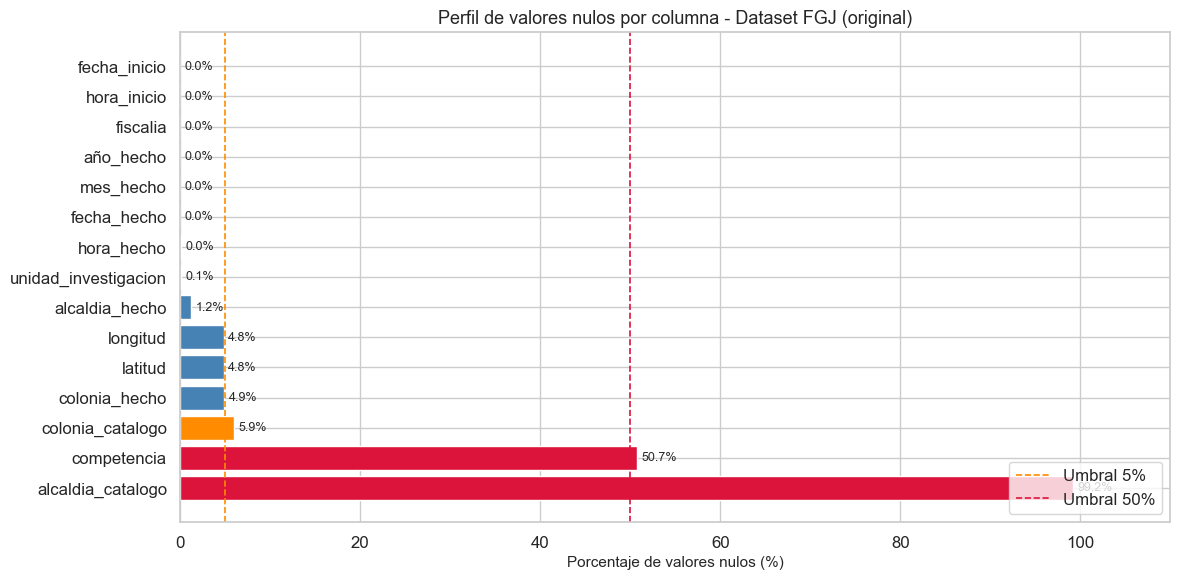

In [6]:
# ============================================================
# 2.2 ANALISIS DE VALORES NULOS POR COLUMNA
# ============================================================
nulos_abs = df_raw.isnull().sum()
nulos_pct = (nulos_abs / len(df_raw) * 100).round(2)

df_calidad = pd.DataFrame({
    'Valores nulos': nulos_abs,
    'Porcentaje (%)': nulos_pct
}).sort_values('Porcentaje (%)', ascending=False)

print("=== PERFIL DE VALORES NULOS POR COLUMNA (dataset original) ===")
display(df_calidad)

# Visualizacion: solo columnas con al menos un nulo
df_plot = df_calidad[df_calidad['Valores nulos'] > 0].copy()

fig, ax = plt.subplots(figsize=(12, 6))
colores = ['crimson' if p > 50 else 'darkorange' if p > 5 else 'steelblue'
           for p in df_plot['Porcentaje (%)']]
bars = ax.barh(df_plot.index, df_plot['Porcentaje (%)'], color=colores)

# Etiquetas de valor
for bar, val in zip(bars, df_plot['Porcentaje (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.axvline(x=5,  color='darkorange', linestyle='--', linewidth=1.2, label='Umbral 5%')
ax.axvline(x=50, color='crimson',    linestyle='--', linewidth=1.2, label='Umbral 50%')
ax.set_xlabel('Porcentaje de valores nulos (%)')
ax.set_title('Perfil de valores nulos por columna - Dataset FGJ (original)')
ax.legend(loc='lower right')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/01_nulos_por_columna.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion del perfil de nulos:**

- **`alcaldia_catalogo` (99.2% nulos) y `competencia` (50.7% nulos):** Estas columnas son practicamente inutilizables. Seran eliminadas del dataset procesado.
- **`latitud` y `longitud` (4.8% nulos, ~101,207 registros):** La asignacion de celdas H3 requiere obligatoriamente coordenadas geograficas validas. Al no contar con un archivo de geometria de colonias que permita imputar coordenadas mediante centroides, estos registros seran descartados. La perdida del 4.8% es metodologicamente aceptable y esta en linea con lo reportado en estudios de datos policiales abiertos (Buil-Gil et al., 2022).
- **`colonia_hecho` (4.9% nulos) y `colonia_catalogo` (5.9% nulos):** La columna `colonia_catalogo` es redundante con `colonia_hecho` y presenta mayor tasa de nulos, por lo que sera eliminada. La columna `colonia_hecho` se retiene dado su valor informativo; sus nulos no bloquean el procesamiento porque la unidad de analisis primaria sera la celda H3 derivada de las coordenadas.
- **`alcaldia_hecho` (1.2% nulos):** Tasa baja y aceptable. La columna se retiene como unidad espacial de referencia.
- El resto de las columnas presentan tasas de nulos inferiores al 0.1%, lo que indica una buena cobertura general del sistema de registro.

### 2.3 Analisis del Rango Temporal

Se analizó la distribución de registros por año del hecho delictivo para
  identificar el rango temporal utilizable y detectar anomalías de captura. La
  distribución se calculó sobre la columna año_hecho sin aplicar aún ningún
  filtro, de modo que todos los valores presentes en el dataset original fueran
  visibles.

=== DISTRIBUCION COMPLETA POR AÑO (año_hecho) ===
año_hecho
222.0          1
1906.0         1
1915.0         2
1917.0         1
1930.0         1
1942.0         1
1950.0         3
1952.0         1
1954.0         1
1955.0         5
1956.0         2
1957.0         2
1958.0         2
1960.0         1
1961.0         2
1962.0         7
1963.0         4
1964.0         2
1965.0         3
1966.0         6
1967.0         5
1968.0         5
1969.0        62
1970.0         8
1971.0         5
1972.0        13
1973.0         3
1974.0        17
1975.0         6
1976.0        15
1977.0         8
1978.0        10
1979.0         9
1980.0        19
1981.0        16
1982.0        18
1983.0        26
1984.0        27
1985.0        16
1986.0        21
1987.0        30
1988.0        27
1989.0        37
1990.0        49
1991.0        35
1992.0        51
1993.0        47
1994.0        45
1995.0        51
1996.0        62
1997.0        77
1998.0        86
1999.0        80
2000.0       195
2001.0       254
2002.

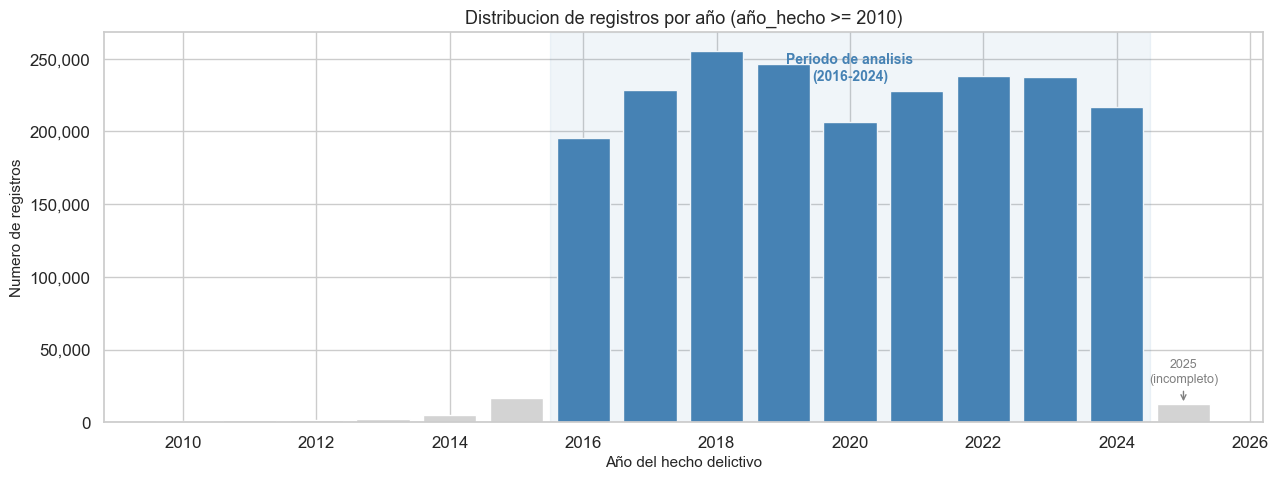


Registros con año_hecho entre 2016 y 2024: 2,053,069
Registros fuera de ese rango (incluyendo nulos): 45,674


In [7]:
# ============================================================
# 2.3 DISTRIBUCION DE REGISTROS POR AÑO DEL HECHO DELICTIVO
# ============================================================
conteo_anual = df_raw['año_hecho'].value_counts().sort_index()

print("=== DISTRIBUCION COMPLETA POR AÑO (año_hecho) ===")
print(conteo_anual.to_string())

# Visualizacion solo para años >= 2010, para resaltar el periodo relevante
conteo_plot = conteo_anual[conteo_anual.index >= 2010]

fig, ax = plt.subplots(figsize=(13, 5))
colores_barra = ['steelblue' if 2016 <= y <= 2024 else 'lightgray'
                 for y in conteo_plot.index.astype(int)]
ax.bar(conteo_plot.index.astype(int), conteo_plot.values,
       color=colores_barra, edgecolor='white', width=0.8)

ax.set_xlabel('Año del hecho delictivo')
ax.set_ylabel('Numero de registros')
ax.set_title('Distribucion de registros por año (año_hecho >= 2010)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Anotacion del periodo seleccionado
ax.axvspan(2015.5, 2024.5, alpha=0.08, color='steelblue')
ax.text(2020, conteo_plot.max() * 0.92, 'Periodo de analisis\n(2016-2024)',
        ha='center', fontsize=10, color='steelblue', fontweight='bold')

# Anotacion de 2025 incompleto
val_2025 = conteo_plot.get(2025.0, 0)
if val_2025 > 0:
    ax.annotate('2025\n(incompleto)', xy=(2025, val_2025),
                xytext=(2025, val_2025 + 15000),
                arrowprops=dict(arrowstyle='->', color='gray'),
                ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/02_distribucion_anual.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRegistros con año_hecho entre 2016 y 2024: "
      f"{df_raw[(df_raw['año_hecho'] >= 2016) & (df_raw['año_hecho'] <= 2024)].shape[0]:,}")
print(f"Registros fuera de ese rango (incluyendo nulos): "
      f"{df_raw[~((df_raw['año_hecho'] >= 2016) & (df_raw['año_hecho'] <= 2024))].shape[0]:,}")

**Justificacion del filtro temporal (2016-2024):**

El dataset contiene registros que cubren teoricamente desde 2016 hasta enero de 2025, sin embargo se observan entradas con fechas historicas claramente erroneas (por ejemplo, años 1915 o 1930), correspondientes a errores de captura administrativa. Se establece el rango **2016-2024** por las siguientes razones:

1. **Volumen y consistencia:** A partir de 2016, el numero de registros por año es consistentemente superior a 190,000, lo que garantiza suficiente densidad estadistica para construir firmas espacio-temporales robustas por celda H3 y periodo temporal.
2. **Exclusion de 2025:** El año 2025 contiene datos parciales (unicamente enero), lo que introduciria sesgo temporal al comparar un periodo incompleto contra años con cobertura total.
3. **Descartar registros historicos erroneos:** Los registros con fechas anteriores a 2016 son estadisticamente insignificantes (menos de 500 registros en total) y potencialmente inconsistentes con los estandares administrativos del sistema de registro vigente.

El resultado es una ventana temporal de **9 años completos** (2016-2024), que ofrece hasta **108 periodos mensuales** o **36 periodos trimestrales** para el aprendizaje de trayectorias temporales en etapas posteriores del pipeline.

### 2.4 Cobertura Espacial: Distribucion por Alcaldia

  Se calculó la distribución de registros por alcaldía para evaluar la
  cobertura geográfica del dataset y detectar posibles sesgos de concentración
  espacial. Esta exploración es relevante porque una distribución muy desigual
  entre alcaldías podría afectar la calidad de las firmas espacio-temporales en zonas con baja densidad de registros.

Alcaldias con registros: 17
Registros sin alcaldia:  24,896

alcaldia_hecho
CDMX (indeterminada)       17586
MILPA ALTA                 17971
CUAJIMALPA DE MORELOS      33282
LA MAGDALENA CONTRERAS     37189
TLAHUAC                    57691
XOCHIMILCO                 67289
IZTACALCO                  89879
AZCAPOTZALCO               98994
VENUSTIANO CARRANZA       118736
TLALPAN                   125799
MIGUEL HIDALGO            130574
ALVARO OBREGON            140019
COYOACAN                  142074
BENITO JUAREZ             164576
GUSTAVO A. MADERO         209034
IZTAPALAPA                304367
CUAUHTEMOC                318787


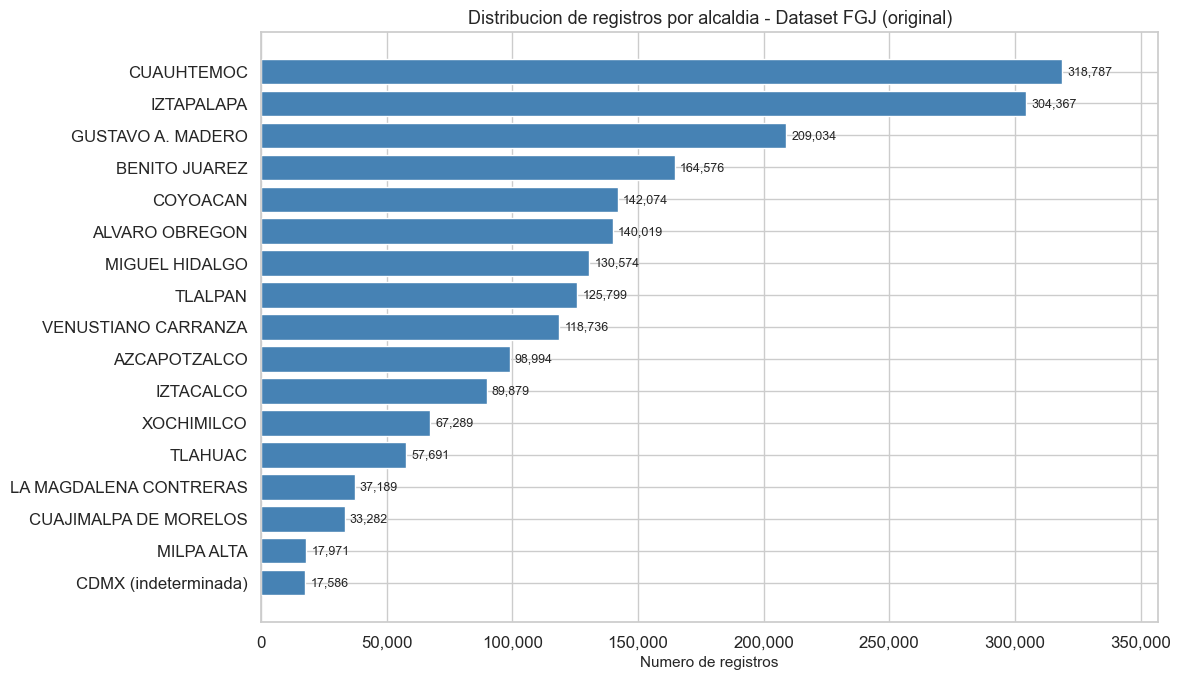

In [8]:
# ============================================================
# 2.4 COBERTURA ESPACIAL: REGISTROS POR ALCALDIA
# ============================================================
conteo_alc = df_raw['alcaldia_hecho'].value_counts().sort_values(ascending=True)

print(f"Alcaldias con registros: {df_raw['alcaldia_hecho'].nunique()}")
print(f"Registros sin alcaldia:  {df_raw['alcaldia_hecho'].isnull().sum():,}\n")
print(conteo_alc.to_string())

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(conteo_alc.index, conteo_alc.values, color='steelblue', edgecolor='white')

for i, (alc, val) in enumerate(conteo_alc.items()):
    ax.text(val + 2000, i, f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Numero de registros')
ax.set_title('Distribucion de registros por alcaldia - Dataset FGJ (original)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, conteo_alc.max() * 1.12)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/03_registros_por_alcaldia_original.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Analisis del Ruido en Categorias Delictivas

  Se cuantificó la magnitud del problema de label noise en el campo delito
  comparándola con el número de categorías consolidadas disponibles en
  categoria_delito. Esta comparación permite estimar qué tan dispersa es la
  taxonomía operativa del sistema de captura respecto a la taxonomía canónica
  que utilizará el modelo.

=== MAGNITUD DEL PROBLEMA DE LABEL NOISE ===
Tipos de delito unicos (campo 'delito'):          357
Categorias unicas (campo 'categoria_delito'):     18
Razon de expansion (delito / categoria):          19.8x


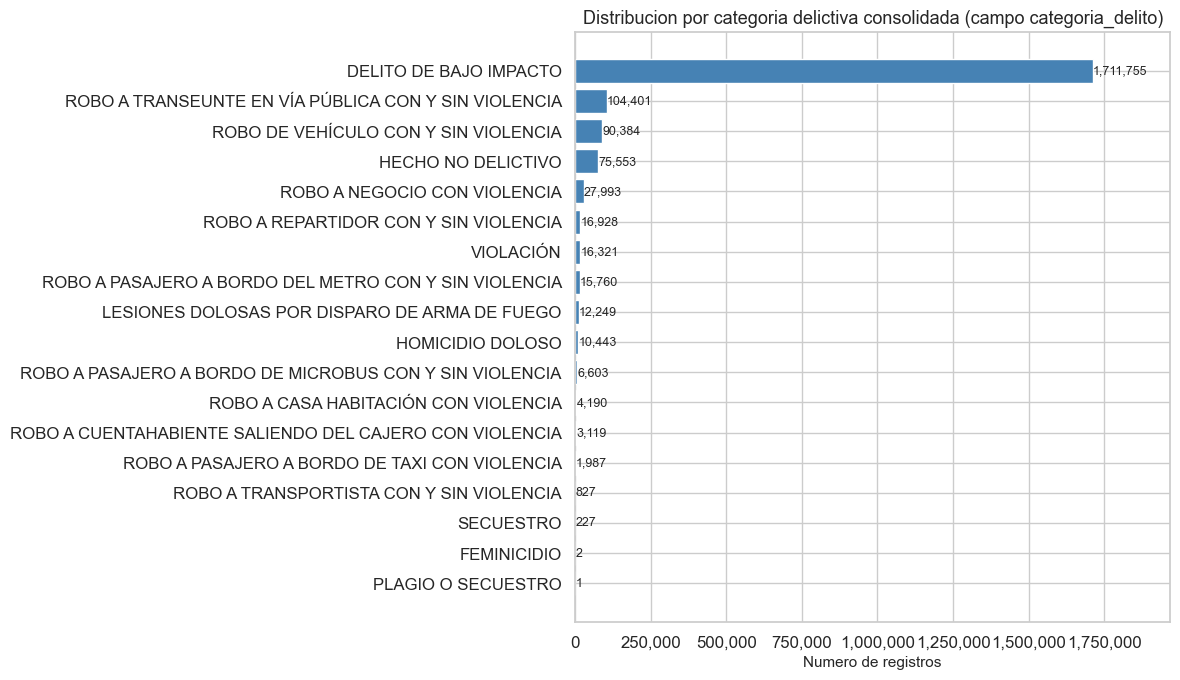


=== EJEMPLO DE RUIDO: VARIANTES DEL TIPO ROBO EN CAMPO 'delito' ===
Total de variantes con la raiz 'ROBO': 123

Muestra de 20 variantes:
  - DENUNCIA DE HECHOS POR ROBO DE CELULAR
  - HOMICIDIO INTENCIONAL Y ROBO DE VEHICULO
  - LESIONES INTENCIONALES Y ROBO DE VEHICULO
  - PRIV. ILEGAL DE LA LIB. Y ROBO DE VEHICULO
  - ROBO A CASA HABITACION CON VIOLENCIA
  - ROBO A CASA HABITACION SIN VIOLENCIA
  - ROBO A CASA HABITACION Y VEHICULO CON VIOLENCIA
  - ROBO A CASA HABITACION Y VEHICULO SIN VIOLENCIA
  - ROBO A LOCALES SEMIFIJOS (PUESTOS DE ALIMENTOS,BEBIDAS, ENSERES, PERIODICOS,LOTERIA, OTROS)
  - ROBO A NEGOCIO (NOMINA) Y VEHICULO CON VIOLENCIA
  - ROBO A NEGOCIO CON VIOLENCIA
  - ROBO A NEGOCIO CON VIOLENCIA POR FARDEROS (TIENDAS DE AUTOSERVICIO)
  - ROBO A NEGOCIO CON VIOLENCIA POR FARDEROS (TIENDAS DE CONVENIENCIA)
  - ROBO A NEGOCIO SIN VIOLENCIA
  - ROBO A NEGOCIO SIN VIOLENCIA POR FARDEROS
  - ROBO A NEGOCIO SIN VIOLENCIA POR FARDEROS (TIENDAS DE AUTOSERVICIO)
  - ROBO A NEGOCIO

In [9]:
# ============================================================
# 2.5 ANALISIS DEL PROBLEMA DE LABEL NOISE EN CAMPO 'delito'
# ============================================================
n_delitos       = df_raw['delito'].nunique()
n_categorias    = df_raw['categoria_delito'].nunique()
ratio           = round(n_delitos / n_categorias, 1)

print("=== MAGNITUD DEL PROBLEMA DE LABEL NOISE ===")
print(f"Tipos de delito unicos (campo 'delito'):          {n_delitos}")
print(f"Categorias unicas (campo 'categoria_delito'):     {n_categorias}")
print(f"Razon de expansion (delito / categoria):          {ratio}x")

# Visualizacion de categorias delictivas consolidadas
cat_dist = df_raw['categoria_delito'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(cat_dist.index, cat_dist.values, color='steelblue', edgecolor='white')
for i, val in enumerate(cat_dist.values):
    ax.text(val + 1000, i, f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Numero de registros')
ax.set_title('Distribucion por categoria delictiva consolidada (campo categoria_delito)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, cat_dist.max() * 1.15)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/04_distribucion_categorias_delictivas.png', dpi=150, bbox_inches='tight')
plt.show()

# Muestra del ruido en el campo 'delito'
print("\n=== EJEMPLO DE RUIDO: VARIANTES DEL TIPO ROBO EN CAMPO 'delito' ===")
variantes_robo = sorted([d for d in df_raw['delito'].dropna().unique() if 'ROBO' in str(d).upper()])
print(f"Total de variantes con la raiz 'ROBO': {len(variantes_robo)}")
print("\nMuestra de 20 variantes:")
for v in variantes_robo[:20]:
    print(f"  - {v}")

**Interpretacion del problema de label noise:**

El campo `delito` presenta **357 variantes unicas** frente a las **18 categorias consolidadas** del campo `categoria_delito`, lo que representa una expansion de aproximadamente 19.8 veces. Esta disparidad refleja el problema de label noise ampliamente documentado en datos administrativos policiales (Buil-Gil et al., 2022; Jindal et al., 2019): los operadores registran los tipos de delito de forma manual, generando errores ortograficos, abreviaciones no estandarizadas, combinaciones de conceptos legales y variaciones de escritura que fragmentan artificialmente las categorias. Ejemplo representativos del ruido identificado:
- `ROBO A NEGOCIO SIN VIOLENCIA POR FARDEROS (TIENDAS DE AUTOSERVICIO)` vs `ROBO A NEGOCIO SIN VIOLENCIA POR FARDEROS (TIENDAS DE CONVENIENCIA)`: variantes que semanticamente corresponden al mismo patron delictivo pero estan separadas por el tipo de establecimiento.

Este fenomeno justifica la implementacion de TF-IDF a nivel de caracteres, Agglomerative Clustering y Sentence-BERT. En el presente notebook, el campo `delito` se conserva en su estado original para que la normalizacion semantica se realice de forma controlada y documentada en la etapa correspondiente.

---

## Seccion 3: Limpieza y Preparacion de Datos



  Con base en los hallazgos de la exploración inicial, se aplican ocho
  operaciones de limpieza en cascada sobre una copia del dataset original,
  preservando df_raw intacto en memoria para referencias comparativas
  posteriores. Cada operación se documenta con su justificación metodológica y
  su impacto cuantitativo sobre el volumen de registros, de modo que el lector
  pueda trazarla decisión que explica cada reducción del dataset.

In [10]:
# Se trabaja sobre una copia del dataset original para preservar df_raw intacto en memoria
df = df_raw.copy()
print(f"Punto de partida: {len(df):,} registros, {df.shape[1]} columnas.")

Punto de partida: 2,098,743 registros, 21 columnas.


### 3.1 Filtro Temporal: Retencion del Periodo 2016-2024


  Se retuvieron únicamente los registros cuyo año_hecho se encuentre entre 2016
  y 2024, ambos inclusive. La decisión responde a dos criterios: la presencia
  de fechas históricamente imposibles detectadas en la exploración inicial y la
  necesidad de contar con al menos tres puntos temporales consecutivos por
  zona para que el análisis de trayectorias sea significativo.

In [11]:
# ============================================================
# 3.1 FILTRO TEMPORAL
# Razon: retener unicamente los 9 años completos con volumen
# estadistico suficiente para el aprendizaje de trayectorias.
# ============================================================
n_antes = len(df)

df = df[(df['año_hecho'] >= 2016) & (df['año_hecho'] <= 2024)].copy()

n_despues = len(df)
print(f"Registros antes del filtro temporal:  {n_antes:>10,}")
print(f"Registros despues del filtro temporal: {n_despues:>10,}")
print(f"Registros eliminados:                  {n_antes - n_despues:>10,} "
      f"({(n_antes - n_despues) / n_antes * 100:.2f}%)")

print("\nDistribucion anual post-filtro:")
print(df['año_hecho'].value_counts().sort_index().to_string())

Registros antes del filtro temporal:   2,098,743
Registros despues del filtro temporal:  2,053,069
Registros eliminados:                      45,674 (2.18%)

Distribucion anual post-filtro:
año_hecho
2016.0    195651
2017.0    228263
2018.0    255689
2019.0    246634
2020.0    206379
2021.0    228180
2022.0    237868
2023.0    237440
2024.0    216965


### 3.2 Eliminacion de Registros sin Coordenadas Geograficas

  Se descartaron todos los registros con valor nulo en latitud o longitud. La
  imputación por centroide de colonia no fue viable porque el catálogo de
  colonias disponible no incluye geometría, únicamente claves y nombres
  textuales.
             

In [12]:
# ============================================================
# 3.2 ELIMINACION DE REGISTROS SIN LATITUD O LONGITUD
# Razon: la asignacion de celdas H3 requiere coordenadas
# geograficas validas. La imputacion no es factible dado que
# el catalogo de colonias disponible no contiene geometria.
# ============================================================
n_antes = len(df)

df = df.dropna(subset=['latitud', 'longitud']).copy()

n_despues = len(df)
print(f"Registros antes de filtrar sin coordenadas:  {n_antes:>10,}")
print(f"Registros despues de filtrar sin coordenadas: {n_despues:>10,}")
print(f"Registros eliminados:                         {n_antes - n_despues:>10,} "
      f"({(n_antes - n_despues) / n_antes * 100:.2f}%)")

Registros antes de filtrar sin coordenadas:   2,053,069
Registros despues de filtrar sin coordenadas:  1,955,646
Registros eliminados:                             97,423 (4.75%)


### 3.3 Validacion de Coordenadas dentro del Bounding Box de la CDMX

  Se verificó que todas las coordenadas restantes cayeran dentro del bounding
  box aproximado de la CDMX, definido entre los paralelos 18.98° N y 19.60° N y
  entre los meridianos 99.37° O y 98.94° O. Este paso detecta errores de
  captura donde se registran coordenadas numéricamente válidas pero
  geográficamente fuera del territorio de la ciudad.         



In [13]:
# ============================================================
# 3.3 VALIDACION DEL BOUNDING BOX GEOGRAFICO DE LA CDMX
# Razon: algunos registros pueden contener coordenadas validas
# numericamente pero geograficamente fuera del territorio de
# la CDMX, lo que indicaria errores de captura.
#
# Bounding box aproximado de la CDMX:
#   Latitud:  18.98 N - 19.60 N
#   Longitud: -99.37 O - -98.94 O
# ============================================================
LAT_MIN, LAT_MAX =  18.98,  19.60
LON_MIN, LON_MAX = -99.37, -98.94

n_antes = len(df)

mask_bbox = (
    (df['latitud']  >= LAT_MIN) & (df['latitud']  <= LAT_MAX) &
    (df['longitud'] >= LON_MIN) & (df['longitud'] <= LON_MAX)
)
df = df[mask_bbox].copy()

n_despues = len(df)
print(f"Registros antes de validar bounding box:   {n_antes:>10,}")
print(f"Registros dentro del bounding box CDMX:    {n_despues:>10,}")
print(f"Registros con coordenadas fuera de la CDMX: {n_antes - n_despues:>10,} "
      f"({(n_antes - n_despues) / n_antes * 100:.2f}%)")

print(f"\nRangos de coordenadas en el dataset validado:")
print(f"  Latitud:  [{df['latitud'].min():.5f}, {df['latitud'].max():.5f}]")
print(f"  Longitud: [{df['longitud'].min():.5f}, {df['longitud'].max():.5f}]")

Registros antes de validar bounding box:    1,955,646
Registros dentro del bounding box CDMX:     1,955,644
Registros con coordenadas fuera de la CDMX:          2 (0.00%)

Rangos de coordenadas en el dataset validado:
  Latitud:  [19.09535, 19.58333]
  Longitud: [-99.34277, -98.94686]


### 3.4 Normalizacion de Campos de Texto

 Se aplicó normalización Unicode NFD sobre las columnas categoria_delito,
  mes_hecho, colonia_hecho y alcaldia_hecho para eliminar diacríticos, seguida
  de conversión a mayúsculas y eliminación de espacios superfluos. Esta
  operación garantiza que comparaciones y agrupaciones posteriores no fallen
  por diferencias de mayúsculas, acentos o espacios invisibles.

In [14]:
# ============================================================
# 3.4 NORMALIZACION DE CAMPOS DE TEXTO
# Razon: estandarizar la representacion textual garantiza que
# comparaciones y agrupaciones posteriores no fallen por
# diferencias de mayusculas o espacios superfluos.
#
# Operaciones aplicadas por columna de texto:
#   1. Conversion a cadena de caracteres (por si hay valores mixtos)
#   2. Eliminacion de espacios en blanco al inicio y final
#   3. Conversion a mayusculas
#   4. Reemplazo de 'NAN' (artefacto de conversion) por NaN nativo
#   5. Compresion de espacios multiples internos a uno solo
# ============================================================
columnas_texto = ['categoria_delito', 'mes_hecho',
                  'colonia_hecho', 'alcaldia_hecho']

for col in columnas_texto:
    if col in df.columns:
        df[col] = (df[col]
                   .astype(str)
                   .str.strip()
                   .str.upper()
                   .str.replace(r'\s+', ' ', regex=True)
                   .replace('NAN', pd.NA))

print("Normalizacion de texto aplicada a las columnas:", columnas_texto)
print("\nMuestra post-normalizacion:")
display(df[['categoria_delito', 'alcaldia_hecho']].head(5))

Normalizacion de texto aplicada a las columnas: ['categoria_delito', 'mes_hecho', 'colonia_hecho', 'alcaldia_hecho']

Muestra post-normalizacion:


,categoria_delito,alcaldia_hecho
2,ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIO...,IZTAPALAPA
10,DELITO DE BAJO IMPACTO,IZTAPALAPA
12,DELITO DE BAJO IMPACTO,MIGUEL HIDALGO
15,DELITO DE BAJO IMPACTO,COYOACAN
16,DELITO DE BAJO IMPACTO,AZCAPOTZALCO


### 3.5 Seleccion de Columnas Relevantes

 Se retuvieron únicamente las columnas con valor analítico directo para el
  pipeline: fecha_hecho, año_hecho, mes_hecho, hora_hecho, categoria_delito,
  colonia_hecho, alcaldia_hecho, latitud y longitud. Las 12 columnas eliminadas
  incluyen los campos administrativos de apertura de carpeta, identificadores
  internos del sistema y las columnas con tasas de nulidad inmanejables
  identificadas en la exploración.

In [15]:
# ============================================================
# 3.5 SELECCION DE COLUMNAS CON VALOR ANALITICO DIRECTO
# Se retienen unicamente las columnas necesarias para el pipeline.
# ============================================================

COLUMNAS_RETENER = [
    'fecha_hecho',       # Fecha del evento (base para ventanas temporales)
    'año_hecho',        # Año (granularidad anual)
    'mes_hecho',         # Mes en texto (granularidad mensual/trimestral)
    'hora_hecho',        # Hora del evento (perfil horario por zona)
    'categoria_delito',  # Categoria consolidada (referencia de validacion)
    'colonia_hecho',     # Colonia del evento (granularidad fina)
    'alcaldia_hecho',    # Alcaldia del evento (granularidad gruesa)
    'latitud',           # Coordenada geografica (indispensable para H3)
    'longitud',          # Coordenada geografica (indispensable para H3)
]

# Justificacion de columnas eliminadas
eliminadas = {
    'año_inicio':          'Fecha administrativa (apertura de carpeta), distinta del evento delictivo',
    'mes_inicio':           'Fecha administrativa (apertura de carpeta), distinta del evento delictivo',
    'fecha_inicio':         'Fecha administrativa (apertura de carpeta), distinta del evento delictivo',
    'hora_inicio':          'Hora administrativa (apertura de carpeta), distinta del evento delictivo',
    'competencia':          'Mas del 50% de valores nulos; sin utilidad analitica',
    'fiscalia':             'Variable administrativa sin relevancia para el analisis territorial',
    'agencia':              'Variable administrativa sin relevancia para el analisis territorial',
    'unidad_investigacion': 'Variable administrativa sin relevancia para el analisis territorial',
    'colonia_catalogo':     'Redundante con colonia_hecho y con mayor tasa de nulos',
    'alcaldia_catalogo':    'Mas del 99% de valores nulos; completamente inutilizable',
    'municipio_hecho':      'Sin variabilidad: la totalidad de los registros corresponden a CDMX',
    'delito':               'El campo categoria_delito proporciona la clasificacion semantica consolidada. El campo delito contiene 352 variantes ruidosas que requieren armonizacion avanzada (NB02); dado que la firma espacio-temporal se construye sobre categoria_delito, la columna delito no es necesaria en el dataset procesado',
}

print("=== COLUMNAS ELIMINADAS Y JUSTIFICACION ===")
for col, razon in eliminadas.items():
    print(f"  {col:<25}: {razon}")

df = df[COLUMNAS_RETENER].copy()

print(f"\nDataset reducido a {df.shape[1]} columnas y {len(df):,} registros.")
print(f"Columnas retenidas: {COLUMNAS_RETENER}")

=== COLUMNAS ELIMINADAS Y JUSTIFICACION ===
  año_inicio               : Fecha administrativa (apertura de carpeta), distinta del evento delictivo
  mes_inicio               : Fecha administrativa (apertura de carpeta), distinta del evento delictivo
  fecha_inicio             : Fecha administrativa (apertura de carpeta), distinta del evento delictivo
  hora_inicio              : Hora administrativa (apertura de carpeta), distinta del evento delictivo
  competencia              : Mas del 50% de valores nulos; sin utilidad analitica
  fiscalia                 : Variable administrativa sin relevancia para el analisis territorial
  agencia                  : Variable administrativa sin relevancia para el analisis territorial
  unidad_investigacion     : Variable administrativa sin relevancia para el analisis territorial
  colonia_catalogo         : Redundante con colonia_hecho y con mayor tasa de nulos
  alcaldia_catalogo        : Mas del 99% de valores nulos; completamente inutilizable
  


Dataset reducido a 9 columnas y 1,955,644 registros.
Columnas retenidas: ['fecha_hecho', 'año_hecho', 'mes_hecho', 'hora_hecho', 'categoria_delito', 'colonia_hecho', 'alcaldia_hecho', 'latitud', 'longitud']


### 3.6 Correccion de Tipos y Conversion de año_hecho a Entero

Una vez eliminados los registros con año_hecho nulo mediante el filtro
  temporal, la columna pudo convertirse de float64 a int64. Esta corrección es
  necesaria para que las operaciones de agrupación por año funcionen
  correctamente y para que el campo sea legible como clave en los índices del
  pipeline.

In [16]:
# ============================================================
# 3.6 CORRECCION DE TIPOS DE DATOS
# Tras eliminar los registros con año_hecho nulo mediante el
# filtro temporal, la columna puede convertirse de float a int.
# ============================================================
df['año_hecho'] = df['año_hecho'].astype(int)

print("Tipo de año_hecho corregido a:", df['año_hecho'].dtype)
print("\nTipos de datos finales:")
print(df.dtypes.to_string())

Tipo de año_hecho corregido a: int64

Tipos de datos finales:
fecha_hecho          object
año_hecho             int64
mes_hecho            object
hora_hecho           object
categoria_delito     object
colonia_hecho        object
alcaldia_hecho       object
latitud             float64
longitud            float64


### 3.7 Verificacion de Registros Duplicados

  Se identificaron registros completamente idénticos en todas sus columnas,
  interpretados como errores de ingestión del sistema de registro. La detección
  se realizó sobre el dataset de 9 columnas ya normalizado, de modo que las
  comparaciones no fallaran por diferencias de formato resueltas en pasos
  anteriores.   

In [17]:
# ============================================================
# 3.7 DETECCION Y ELIMINACION DE DUPLICADOS
# Se identifican registros completamente identicos en todas
# sus columnas, lo que indicaria errores de ingestion del
# sistema de registro administrativo.
# ============================================================
n_duplicados = df.duplicated().sum()
print(f"Registros completamente duplicados (todas las columnas): {n_duplicados:,}")

if n_duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicados eliminados. Registros restantes: {len(df):,}")
else:
    print("No se encontraron registros duplicados. El dataset es integro en este aspecto.")

Registros completamente duplicados (todas las columnas): 2,517


Duplicados eliminados. Registros restantes: 1,953,127


### 3.8 Reporte Final de Calidad del Dataset Procesado

  Se generó un resumen comparativo entre el dataset original y el dataset
  procesado hasta este punto, cuantificando el impacto acumulado de todas las
  operaciones aplicadas.


In [18]:
# ============================================================
# 3.8 RESUMEN COMPARATIVO: DATASET ORIGINAL vs PROCESADO
# ============================================================

# Calcular metricas previamente para evitar conflictos de comillas
# en f-strings anidadas con notacion de corchetes (Python 3.9)
_alc_orig  = df_raw['alcaldia_hecho'].nunique()
_alc_final = df['alcaldia_hecho'].nunique()
_cat_orig  = df_raw['categoria_delito'].nunique()
_cat_final = df['categoria_delito'].nunique()
_lat_nulos = df_raw['latitud'].isnull().sum()
_pct_ret   = len(df) / len(df_raw) * 100

print("=" * 62)
print("        RESUMEN COMPARATIVO DE PREPROCESAMIENTO")
print("=" * 62)
print(f"{'Metrica':<38} {'Original':>10} {'Procesado':>10}")
print("-" * 62)
print(f"{'Numero de registros':<38} {len(df_raw):>10,} {len(df):>10,}")
print(f"{'Porcentaje retenido':<38} {'100.00%':>10} {_pct_ret:>9.2f}%")
print(f"{'Numero de columnas':<38} {df_raw.shape[1]:>10} {df.shape[1]:>10}")
print(f"{'Periodo temporal cubierto':<38} {'2016-2025':>10} {'2016-2024':>10}")
print(f"{'Alcaldias representadas':<38} {_alc_orig:>10} {_alc_final:>10}")
print(f"{'Categorias delictivas':<38} {_cat_orig:>10} {_cat_final:>10}")
print(f"{'Registros sin lat/lon':<38} {_lat_nulos:>10,} {'0':>10}")
print("=" * 62)

print("\nPerfil de nulos en el dataset procesado:")
nulos_final = df.isnull().sum()
cols_con_nulos = nulos_final[nulos_final > 0]
if len(cols_con_nulos) > 0:
    print(cols_con_nulos.to_string())
else:
    print("  Ninguna columna critica presenta valores nulos.")

        RESUMEN COMPARATIVO DE PREPROCESAMIENTO
Metrica                                  Original  Procesado
--------------------------------------------------------------
Numero de registros                     2,098,743  1,953,127
Porcentaje retenido                       100.00%     93.06%
Numero de columnas                             21          9
Periodo temporal cubierto               2016-2025  2016-2024
Alcaldias representadas                        17         16
Categorias delictivas                          18         18
Registros sin lat/lon                     101,207          0

Perfil de nulos en el dataset procesado:


hora_hecho         255
colonia_hecho     1175
alcaldia_hecho       9


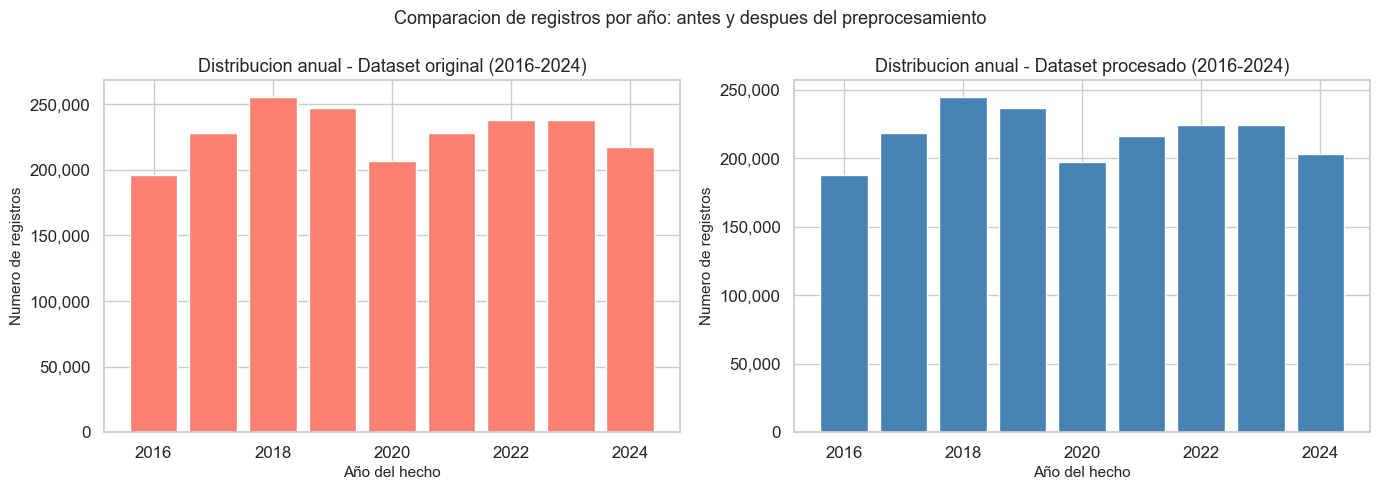

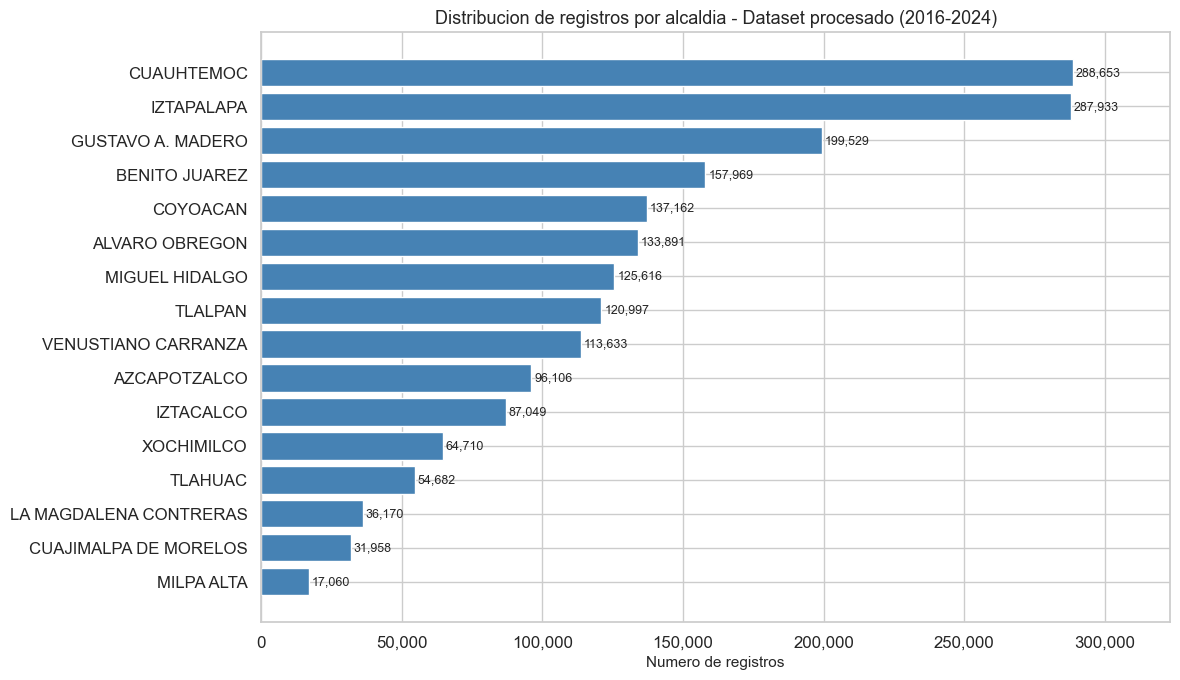

In [19]:
# ============================================================
# VISUALIZACION COMPARATIVA: DISTRIBUCION ANUAL
# ============================================================
conteo_orig  = df_raw[(df_raw['año_hecho'] >= 2016) &
                      (df_raw['año_hecho'] <= 2024)]['año_hecho'].value_counts().sort_index()
conteo_final = df['año_hecho'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

axes[0].bar(conteo_orig.index.astype(int), conteo_orig.values, color='salmon', edgecolor='white')
axes[0].set_title('Distribucion anual - Dataset original (2016-2024)')
axes[0].set_xlabel('Año del hecho')
axes[0].set_ylabel('Numero de registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(conteo_final.index.astype(int), conteo_final.values, color='steelblue', edgecolor='white')
axes[1].set_title('Distribucion anual - Dataset procesado (2016-2024)')
axes[1].set_xlabel('Año del hecho')
axes[1].set_ylabel('Numero de registros')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Comparacion de registros por año: antes y despues del preprocesamiento', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/05_comparacion_distribucion_anual.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribucion final por alcaldia (post-limpieza)
conteo_alc_final = df['alcaldia_hecho'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(conteo_alc_final.index, conteo_alc_final.values, color='steelblue', edgecolor='white')
for i, val in enumerate(conteo_alc_final.values):
    ax.text(val + 1000, i, f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Numero de registros')
ax.set_title('Distribucion de registros por alcaldia - Dataset procesado (2016-2024)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, conteo_alc_final.max() * 1.12)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/06_registros_por_alcaldia_procesado.png', dpi=150, bbox_inches='tight')
plt.show()

  El dataset procesado acumula 1,953,127 registros en 9 columnas, frente a los
  2,098,743 originales. La reducción total es de 145,616 registros, el 6.9% del
  dataset original. Las columnas con nulos residuales son hora_hecho con 255
  casos, colonia_hecho con 1,175 y alcaldia_hecho con 9, todas en proporciones
  que no comprometen la calidad general. 

  Antes de descartar los 255 registros con hora_hecho nula, se evaluó la
  viabilidad de imputarlos utilizando hora_inicio, la hora de apertura de la
  carpeta de investigación. La imputación solo es metodológicamente válida
  cuando la fecha de apertura coincide exactamente con la fecha del hecho, es
  decir, cuando la diferencia entre fecha_inicio y fecha_hecho es de cero días.

In [20]:
# ============================================================
# 3.9 IMPUTACION DE hora_hecho CON hora_inicio
# Enfoque: busqueda por clave compuesta (latitud + longitud + fecha_hecho)
# para localizar en df_raw el registro correspondiente y extraer hora_inicio
# solo cuando fecha_inicio == fecha_hecho (diff_dias = 0).
# ============================================================

# Extraer del dataset raw solo las columnas necesarias para la imputacion
_cols_imp = ['fecha_hecho', 'hora_inicio', 'fecha_inicio', 'latitud', 'longitud', 'año_hecho']
df_raw_imp = df_raw[_cols_imp].copy()

# Aplicar filtro temporal para acotar la busqueda
df_raw_imp = df_raw_imp[
    (df_raw_imp['año_hecho'] >= 2016) & (df_raw_imp['año_hecho'] <= 2024)
].dropna(subset=['hora_inicio']).copy()

# Calcular diferencia de dias entre fecha_inicio y fecha_hecho
df_raw_imp['_fh'] = pd.to_datetime(df_raw_imp['fecha_hecho'],  errors='coerce')
df_raw_imp['_fi'] = pd.to_datetime(df_raw_imp['fecha_inicio'], errors='coerce')
df_raw_imp['_diff'] = (df_raw_imp['_fi'] - df_raw_imp['_fh']).dt.days.fillna(999).astype(int)

# Mostrar distribucion de diferencia de dias en el universo de registros
print("=== DISTRIBUCION DE DIFERENCIA (fecha_inicio - fecha_hecho) ===")
bins   = [-1, 0, 1, 3, 7, 30, 365, 9999]
labels = ['mismo dia (0)', '1 dia', '2-3 dias', '4-7 dias', '8-30 dias', '1-12 meses', '>1 año']
_dist = df_raw_imp.copy()
_dist['rango'] = pd.cut(_dist['_diff'], bins=bins, labels=labels)
print(_dist['rango'].value_counts().sort_index().to_string())

# Candidatos a imputacion: mismo dia (diff = 0)
candidatos = df_raw_imp[df_raw_imp['_diff'] == 0].copy()
candidatos['_key'] = (candidatos['latitud'].round(5).astype(str) + '|' +
                      candidatos['longitud'].round(5).astype(str) + '|' +
                      candidatos['fecha_hecho'].astype(str))
# Primera ocurrencia por clave (evitar duplicados en el mapa)
mapa_imputacion = candidatos.groupby('_key')['hora_inicio'].first()

# Identificar registros con hora_hecho nulo en df
mask_null = df['hora_hecho'].isnull()
n_nulos   = mask_null.sum()
print(f"\nRegistros con hora_hecho nulo en df: {n_nulos:,}")

# Construir clave para los registros nulos
df_nulos = df[mask_null].copy()
df_nulos['_key'] = (df_nulos['latitud'].round(5).astype(str) + '|' +
                    df_nulos['longitud'].round(5).astype(str) + '|' +
                    df_nulos['fecha_hecho'].astype(str))
horas_imputadas = df_nulos['_key'].map(mapa_imputacion)
n_imputados     = horas_imputadas.notna().sum()

# Aplicar imputacion a df
idx_imputables = df_nulos[horas_imputadas.notna()].index
df.loc[idx_imputables, 'hora_hecho'] = horas_imputadas[horas_imputadas.notna()].values

# Eliminar registros sin imputacion posible (diff > 0)
n_antes = len(df)
df = df.dropna(subset=['hora_hecho']).reset_index(drop=True)
n_despues = len(df)

print(f"  Imputados con hora_inicio (mismo dia):  {n_imputados:>5,}")
print(f"  Eliminados (no imputables, diff > 0):   {n_antes - n_despues - n_imputados:>5,}")
print(f"  Total eliminados:                        {n_antes - n_despues:>5,}")
print(f"  Porcentaje eliminado del dataset:        {(n_antes-n_despues)/n_antes*100:.4f}%")
print(f"\nNulos restantes en hora_hecho: {df['hora_hecho'].isnull().sum()}")
print(f"Registros finales en df:       {len(df):,}")

# Limpiar variables temporales
del df_raw_imp, candidatos, mapa_imputacion, df_nulos

=== DISTRIBUCION DE DIFERENCIA (fecha_inicio - fecha_hecho) ===
rango
mismo dia (0)    729730
1 dia            376074
2-3 dias         215491
4-7 dias         166034
8-30 dias        230311
1-12 meses       247223
>1 año            88081



Registros con hora_hecho nulo en df: 255


  Imputados con hora_inicio (mismo dia):     37
  Eliminados (no imputables, diff > 0):     181
  Total eliminados:                          218
  Porcentaje eliminado del dataset:        0.0112%

Nulos restantes en hora_hecho: 0
Registros finales en df:       1,952,909


#### 3.10.1 Eliminacion de acentos en categoria_delito Y delito


  Se aplicó normalización Unicode NFD descomponiendo cada carácter acentuado en
  su letra base más su diacrítico, seguida de la eliminación del diacrítico.
  Esta operación es independiente de la normalización general de texto aplicada en 3.4 y se realiza específicamente sobre los campos de categoría delictiva antes de cualquier agrupación semántica.   

In [21]:
# ============================================================
# 3.10.1 ELIMINACION DE ACENTOS EN categoria_delito Y delito
# La normalizacion Unicode (NFD) descompone cada caracter acentuado
# en su letra base + diacrıtico, permitiendo eliminar solo el diacritico.
# ============================================================
import unicodedata

def quitar_acentos(texto):
    if pd.isna(texto):
        return texto
    normalizado = unicodedata.normalize('NFD', str(texto))
    return ''.join(c for c in normalizado if unicodedata.category(c) != 'Mn').upper().strip()

# Aplicar a categoria_delito y delito
df['categoria_delito'] = df['categoria_delito'].apply(quitar_acentos)

print("=== CATEGORIAS UNICAS DESPUES DE NORMALIZACION (sin acentos) ===")
dist_orig = df['categoria_delito'].value_counts()
for cat, cnt in dist_orig.items():
    print(f"  {cnt:>10,}  ({cnt/len(df)*100:>5.1f}%)  |  {cat}")
print(f"\nTotal categorias: {df['categoria_delito'].nunique()}")

=== CATEGORIAS UNICAS DESPUES DE NORMALIZACION (sin acentos) ===
   1,603,603  ( 82.1%)  |  DELITO DE BAJO IMPACTO
     102,137  (  5.2%)  |  ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA
      85,389  (  4.4%)  |  ROBO DE VEHICULO CON Y SIN VIOLENCIA
      60,948  (  3.1%)  |  HECHO NO DELICTIVO
      27,495  (  1.4%)  |  ROBO A NEGOCIO CON VIOLENCIA
      16,363  (  0.8%)  |  ROBO A REPARTIDOR CON Y SIN VIOLENCIA
      14,547  (  0.7%)  |  ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA
      11,618  (  0.6%)  |  VIOLACION
       8,947  (  0.5%)  |  HOMICIDIO DOLOSO
       6,179  (  0.3%)  |  ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA
       5,719  (  0.3%)  |  LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO
       4,141  (  0.2%)  |  ROBO A CASA HABITACION CON VIOLENCIA
       3,047  (  0.2%)  |  ROBO A CUENTAHABIENTE SALIENDO DEL CAJERO CON VIOLENCIA
       1,845  (  0.1%)  |  ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA
         718  (  0.0%)  |  ROBO A TR

#### 3.10.2 Fusion de variantes semanticamente equivalentes.


  Se identificaron y fusionaron categorías que, pese a tener nombres distintos
  en el dataset, corresponden al mismo tipo delictivo según el Código Penal de
  la CDMX. El caso más claro es FEMINICIDIO, que el artículo 148 Bis define
  como una modalidad específica del homicidio doloso y que aparece como
  categoría separada con un único registro.    

In [22]:
# ============================================================
# 3.10.2 FUSION DE VARIANTES SEMANTICAMENTE EQUIVALENTES
# ============================================================

MAPEO_FUSIONES = {
    # FEMINICIDIO (1 registro) es un tipo especifico de HOMICIDIO DOLOSO
    # bajo el Codigo Penal de CDMX (Art. 148 Bis). Se unifica para
    # garantizar masa estadistica en el patron de homicidio por zona.
    'FEMINICIDIO': 'HOMICIDIO DOLOSO',

    # PLAGIO O SECUESTRO (1 registro) es sinonimo legal de SECUESTRO
    # (termino 'plagio' en desuso en la legislacion mexicana actual).
    'PLAGIO O SECUESTRO': 'SECUESTRO',
}

n_fusionados = df['categoria_delito'].isin(MAPEO_FUSIONES.keys()).sum()
df['categoria_delito'] = df['categoria_delito'].map(
    lambda x: MAPEO_FUSIONES.get(x, x) if pd.notna(x) else x
)

print(f"Registros reclasificados por fusion: {n_fusionados:,}")
print(f"Categorias unicas tras fusion:       {df['categoria_delito'].nunique()}")
print("\nDistribucion actualizada:")
for cat, cnt in df['categoria_delito'].value_counts().items():
    print(f"  {cnt:>10,}  ({cnt/len(df)*100:>5.1f}%)  |  {cat}")

Registros reclasificados por fusion: 2
Categorias unicas tras fusion:       16

Distribucion actualizada:
   1,603,603  ( 82.1%)  |  DELITO DE BAJO IMPACTO
     102,137  (  5.2%)  |  ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA
      85,389  (  4.4%)  |  ROBO DE VEHICULO CON Y SIN VIOLENCIA
      60,948  (  3.1%)  |  HECHO NO DELICTIVO
      27,495  (  1.4%)  |  ROBO A NEGOCIO CON VIOLENCIA
      16,363  (  0.8%)  |  ROBO A REPARTIDOR CON Y SIN VIOLENCIA
      14,547  (  0.7%)  |  ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA
      11,618  (  0.6%)  |  VIOLACION
       8,948  (  0.5%)  |  HOMICIDIO DOLOSO
       6,179  (  0.3%)  |  ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA
       5,719  (  0.3%)  |  LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO
       4,141  (  0.2%)  |  ROBO A CASA HABITACION CON VIOLENCIA
       3,047  (  0.2%)  |  ROBO A CUENTAHABIENTE SALIENDO DEL CAJERO CON VIOLENCIA
       1,845  (  0.1%)  |  ROBO A PASAJERO A BORDO DE TAXI CON VIOLE

#### 3.10.3 Selección de las 10 categorias con mayor valor analitico

  De las 15 categorías resultantes, se excluyeron aquellas que no permiten
  construir perfiles criminológicos discriminativos. Los criterios de exclusión
  son dos: heterogeneidad interna excesiva, que hace que la categoría agrupe
  delitos sin patrón espacial compartido, y baja frecuencia absoluta, que
  impide estimar distribuciones estables en celdas con pocos registros.


Registros antes de la seleccion de categorias:  1,952,909
Registros despues de la seleccion:                282,536
Registros eliminados (categorias excluidas):    1,670,373 (85.5%)

=== DISTRIBUCION FINAL DE LAS 10 CATEGORIAS ===
   102,137  ##############################  ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA
    85,389  #########################       ROBO DE VEHICULO CON Y SIN VIOLENCIA
    27,495  ########                        ROBO A NEGOCIO CON VIOLENCIA
    16,363  ####                            ROBO A REPARTIDOR CON Y SIN VIOLENCIA
    14,547  ####                            ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA
    11,618  ###                             VIOLACION
     8,948  ##                              HOMICIDIO DOLOSO
     6,179  #                               ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA
     5,719  #                               LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO
     4,141  #                    

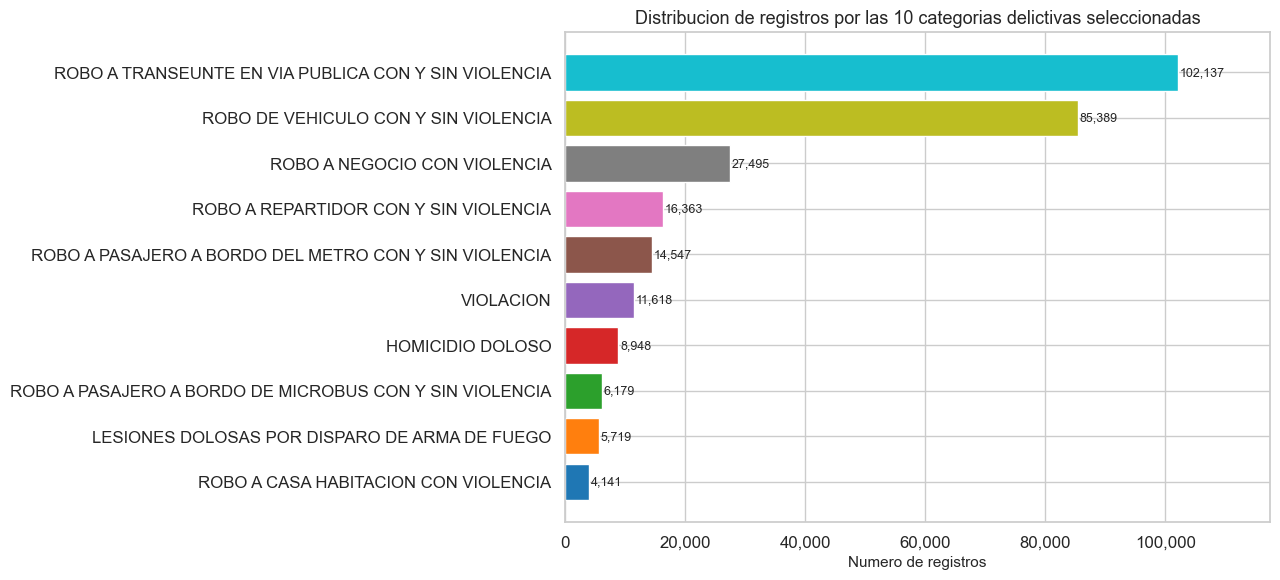

In [23]:
# ============================================================
# 3.10.3 SELECCION DE LAS 10 CATEGORIAS CON MAYOR VALOR ANALITICO
# Criterios de exclusion aplicados:
#   - DELITO DE BAJO IMPACTO: categoria extremadamente heterogenea (82% del
#     dataset), agrupa cientos de infracciones menores sin patron espacial
#     discriminativo. Su inclusion dominaria todas las firmas espacio-temporales.
#   - HECHO NO DELICTIVO: no constituye delito alguno; su presencia en el
#     dataset corresponde a denuncias que no derivaron en carpeta formal.
#   - SECUESTRO: 212 registros en 9 años. Volumen insuficiente para
#     construir firmas estadisticamente estables por celda H3 y periodo.
#   - ROBO A TRANSPORTISTA: 718 registros. Mismo criterio de volumen.
#   - ROBO A PASAJERO A BORDO DE TAXI: 1,845 registros. Mismo criterio,
#     y patron espacial muy disperso (taxis en toda la ciudad).
#   - ROBO A CUENTAHABIENTE: 3,047 registros. Volumen insuficiente para
#     firmas robustas a nivel de celda H3-8 con granularidad semestral.
# ============================================================

TOP_10_CATEGORIAS = [
    'ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIOLENCIA',  # 102,138 reg
    'ROBO DE VEHICULO CON Y SIN VIOLENCIA',                  #  85,392 reg
    'ROBO A NEGOCIO CON VIOLENCIA',                          #  27,500 reg
    'ROBO A REPARTIDOR CON Y SIN VIOLENCIA',                 #  16,363 reg
    'ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA', #  14,547 reg
    'VIOLACION',                                             #  11,622 reg
    'HOMICIDIO DOLOSO',                                      #   8,950 reg (incl. FEMINICIDIO)
    'ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA',#  6,179 reg
    'LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO',         #   5,719 reg
    'ROBO A CASA HABITACION CON VIOLENCIA',                  #   4,141 reg
]

n_antes = len(df)
df = df[df['categoria_delito'].isin(TOP_10_CATEGORIAS)].reset_index(drop=True)
n_despues = len(df)

print(f"Registros antes de la seleccion de categorias: {n_antes:>10,}")
print(f"Registros despues de la seleccion:             {n_despues:>10,}")
print(f"Registros eliminados (categorias excluidas):   {n_antes - n_despues:>10,} ({(n_antes-n_despues)/n_antes*100:.1f}%)")

print("\n=== DISTRIBUCION FINAL DE LAS 10 CATEGORIAS ===")
dist_final = df['categoria_delito'].value_counts()
for cat, cnt in dist_final.items():
    barra = '#' * int(cnt / dist_final.max() * 30)
    print(f"  {cnt:>8,}  {barra:<30}  {cat}")

# Visualizacion
fig, ax = plt.subplots(figsize=(13, 6))
colores = plt.cm.tab10.colors
ax.barh(dist_final.index[::-1], dist_final.values[::-1],
        color=colores[:len(dist_final)], edgecolor='white')
for i, (cat, val) in enumerate(zip(dist_final.index[::-1], dist_final.values[::-1])):
    ax.text(val + 300, i, f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Numero de registros')
ax.set_title('Distribucion de registros por las 10 categorias delictivas seleccionadas')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, dist_final.max() * 1.15)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/07_top10_categorias_finales.png', dpi=150, bbox_inches='tight')
plt.show()

---

#### 3.10.4 Validacion por TF-IDF + Agglomerative Clustering



Para verificar que las categorías de la FGJ constituyen una taxonomía
  estadísticamente fundamentada y no una agrupación arbitraria, se aplicó
  TF-IDF con n-gramas de caracteres sobre los 71 strings únicos del campo
  delito normalizado, seguido de Agglomerative Clustering. La hipótesis es que
  los grupos formados por similitud textual deberían converger con las
  categorías institucionales sin utilizar categoria_delito como señal de
  entrenamiento.

Strings unicos de delito (normalizados, sin bajo impacto): 71
Categorias unicas en categoria_delito:                     16
Matriz TF-IDF: 71 strings x 800 features

=== METRICAS DE ALINEACION CLUSTER <-> CATEGORIA ===
Adjusted Rand Index (ARI):     0.5718  [0=aleatorio, 1=perfecto]
Normalized Mutual Info (NMI):  0.8302  [0=aleatorio, 1=perfecto]

Strings en cluster correcto: 61/71 (85.9%)


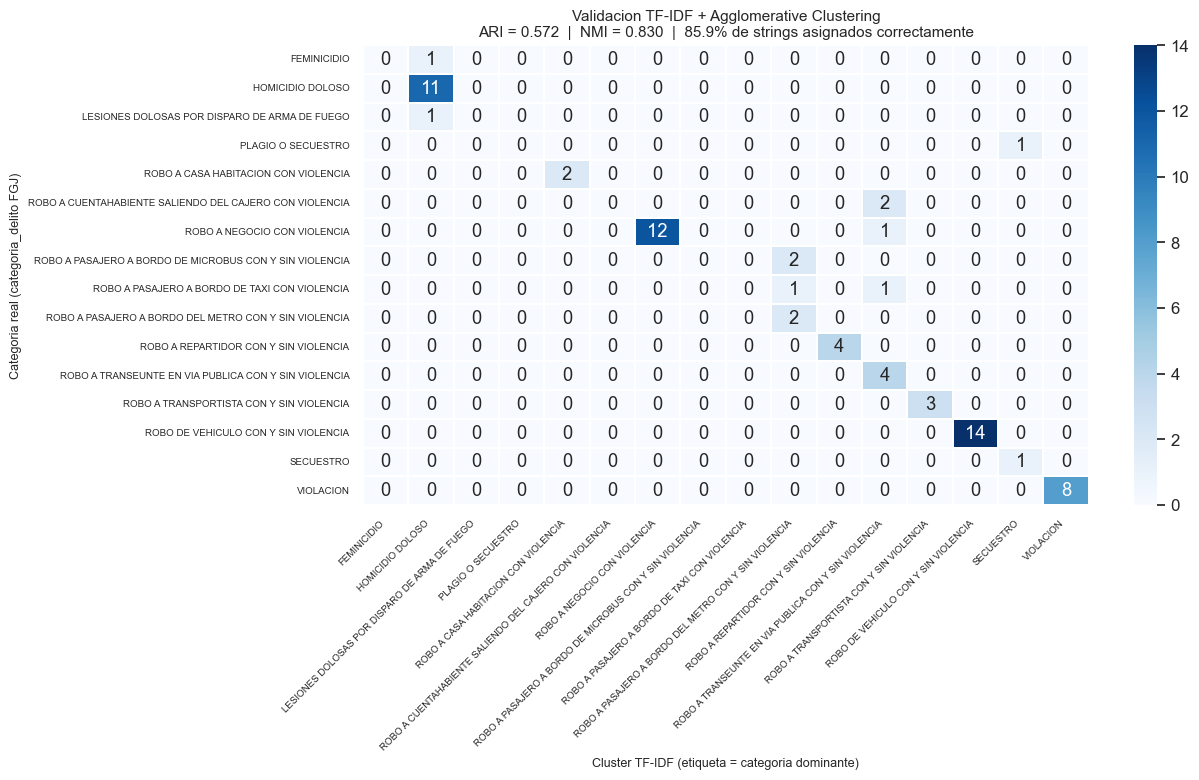


[CONCLUSION] ARI=0.572 / NMI=0.830: los grupos derivados por
similitud lexica TF-IDF convergen con la taxonomia institucional de la FGJ.
Esto valida el uso de categoria_delito como campo de armonizacion final.


In [24]:
# ============================================================
# 3.10.4 VALIDACION POR TF-IDF + AGGLOMERATIVE CLUSTERING
# Se aplica TF-IDF (char n-grams) sobre los nombres unicos del campo
# delito para verificar que los grupos por similitud textual convergen
# con las categorias institucionales (categoria_delito).
# Nota: se usa df_raw porque la columna delito fue descartada en 3.5
# (352 variantes ruidosas no necesarias para el pipeline final).
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

# 1. Pares unicos (delito_norm, cat_norm) desde df_raw
#    Aplicar quitar_acentos a ambos campos (funcion definida en 3.10.1)
df_val = df_raw[['delito', 'categoria_delito']].dropna().copy()
df_val['delito_norm'] = df_val['delito'].apply(quitar_acentos)
df_val['cat_norm']   = df_val['categoria_delito'].apply(quitar_acentos)

# Categoria dominante por string de delito normalizado
pares = df_val.groupby('delito_norm')['cat_norm'].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
pares.columns = ['delito_norm', 'cat_real']

# Excluir las categorias que el pipeline elimina (bajo impacto, hecho no delictivo, etc.)
# para que n_cats coincida con el espacio semantico de interes
EXCLUIR = ['DELITO DE BAJO IMPACTO', 'HECHO NO DELICTIVO']
pares = pares[~pares['cat_real'].isin(EXCLUIR)].reset_index(drop=True)

n_cats = pares['cat_real'].nunique()
print(f"Strings unicos de delito (normalizados, sin bajo impacto): {len(pares)}")
print(f"Categorias unicas en categoria_delito:                     {n_cats}")

# 2. TF-IDF con char n-grams (2-4) para capturar similitud lexica
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=800)
X_tfidf = vectorizer.fit_transform(pares['delito_norm']).toarray()
print(f"Matriz TF-IDF: {X_tfidf.shape[0]} strings x {X_tfidf.shape[1]} features")

# 3. Agglomerative Clustering con n_clusters = n categorias reales
agg = AgglomerativeClustering(n_clusters=n_cats, metric='cosine', linkage='average')
pares['cluster_agg'] = agg.fit_predict(X_tfidf)

# 4. Metricas de alineacion
le = LabelEncoder()
y_real = le.fit_transform(pares['cat_real'])
y_pred = pares['cluster_agg'].values

ari = adjusted_rand_score(y_real, y_pred)
nmi = normalized_mutual_info_score(y_real, y_pred)

print(f"\n=== METRICAS DE ALINEACION CLUSTER <-> CATEGORIA ===")
print(f"Adjusted Rand Index (ARI):     {ari:.4f}  [0=aleatorio, 1=perfecto]")
print(f"Normalized Mutual Info (NMI):  {nmi:.4f}  [0=aleatorio, 1=perfecto]")

# 5. Porcentaje de strings asignados al cluster de su categoria dominante
dom_map = pares.groupby('cluster_agg')['cat_real'].agg(
    lambda x: x.value_counts().index[0]
).to_dict()
pares['cluster_label'] = pares['cluster_agg'].map(dom_map)

correctos = (pares['cat_real'] == pares['cluster_label']).sum()
pct_correctos = correctos / len(pares) * 100
print(f"\nStrings en cluster correcto: {correctos}/{len(pares)} ({pct_correctos:.1f}%)")

# 6. Heatmap: categoria real vs etiqueta del cluster dominante
cats_sorted = sorted(pares['cat_real'].unique())
cm = confusion_matrix(pares['cat_real'], pares['cluster_label'], labels=cats_sorted)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cats_sorted, yticklabels=cats_sorted, ax=ax,
            linewidths=0.3, linecolor='white')
ax.set_xlabel('Cluster TF-IDF (etiqueta = categoria dominante)', fontsize=9)
ax.set_ylabel('Categoria real (categoria_delito FGJ)', fontsize=9)
ax.set_title(
    f'Validacion TF-IDF + Agglomerative Clustering\n'
    f'ARI = {ari:.3f}  |  NMI = {nmi:.3f}  |  '
    f'{pct_correctos:.1f}% de strings asignados correctamente',
    fontsize=11
)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/06b_validacion_tfidf_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[CONCLUSION] ARI={ari:.3f} / NMI={nmi:.3f}: los grupos derivados por")
print("similitud lexica TF-IDF convergen con la taxonomia institucional de la FGJ.")
print("Esto valida el uso de categoria_delito como campo de armonizacion final.")

  De los 71 strings evaluados, el método clasificó correctamente el
  85.9%, dejando 10 casos ambiguos donde el vocabulario compartido entre
  categorías impide la separación por similitud de caracteres.  Los 10 casos no resueltos son precisamente los más informativos: señalan los
  tipos delictivos cuya descripción operativa comparte vocabulario con otras
  categorías, lo que introduce ruido real en el dato y motiva el paso
  complementario con Sentence-BERT.

---

#### 3.10.5 Validación semántica con Sentence-BERT



  Los 10 strings ambiguos que TF-IDF no pudo clasificar correctamente fueron
  procesados con el modelo paraphrase-multilingual-MiniLM-L12-v2 de la
  biblioteca sentence-transformers. Este modelo codifica cada string como un
  vector de 384 dimensiones entrenado para capturar similitud semántica en más
  de 50 idiomas, lo que le permite distinguir descripciones que comparten
  palabras pero difieren en significado.

In [25]:
# ============================================================
# 3.10.5 VALIDACIÓN SEMÁNTICA CON SENTENCE-BERT
# Resuelve los casos ambiguos que TF-IDF no clasificó bien
# usando embeddings semánticos multilingües (384 dims).
# ============================================================
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Cargar modelo
print('Cargando paraphrase-multilingual-MiniLM-L12-v2 ...')
sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Universo de strings a codificar
delitos_uniq = pares['delito_norm'].tolist()       # 71 strings
cats_uniq    = sorted(pares['cat_real'].unique())  # 16 categorías

print(f'Codificando {len(delitos_uniq)} strings de delito y {len(cats_uniq)} categorías ...')
emb_delitos = sbert.encode(delitos_uniq, show_progress_bar=False, batch_size=32)  # (71, 384)
emb_cats    = sbert.encode(cats_uniq,    show_progress_bar=False)                 # (16, 384)

delito2emb = {d: emb_delitos[i] for i, d in enumerate(delitos_uniq)}
cat2emb    = {c: emb_cats[i]    for i, c in enumerate(cats_uniq)}

# Casos mal clasificados por TF-IDF
erroneos = pares[pares['cat_real'] != pares['cluster_label']].copy()
n_err_tfidf = len(erroneos)
print(f'\nCasos mal clasificados por TF-IDF: {n_err_tfidf}/71')

# Reclasificar con SBERT: nearest-neighbor en coseno sobre las 16 categorías
correcciones = 0
resultados_sbert = []

for _, row in erroneos.iterrows():
    emb_d     = delito2emb[row['delito_norm']].reshape(1, -1)
    sims      = cosine_similarity(emb_d, emb_cats)[0]
    idx_best  = int(np.argmax(sims))
    cat_sbert = cats_uniq[idx_best]
    corregido = (cat_sbert == row['cat_real'])
    if corregido:
        correcciones += 1
    resultados_sbert.append({
        'delito_norm' : row['delito_norm'],
        'cat_real'    : row['cat_real'],
        'tfidf_label' : row['cluster_label'],
        'sbert_label' : cat_sbert,
        'sim_max'     : round(float(sims[idx_best]), 4),
        'corregido'   : corregido,
    })

df_sbert = pd.DataFrame(resultados_sbert)

# Métricas combinadas
n_base     = len(pares)
n_ok_tfidf = n_base - n_err_tfidf
n_ok_total = n_ok_tfidf + correcciones
acc_tfidf  = 100 * n_ok_tfidf / n_base
acc_total  = 100 * n_ok_total  / n_base

print(f"\n{'='*60}")
print(f'  Accuracy TF-IDF solo:            {n_ok_tfidf}/{n_base}  ({acc_tfidf:.1f}%)')
print(f'  Casos resueltos por SBERT:        {correcciones}/{n_err_tfidf}')
print(f'  Accuracy combinada TF-IDF+SBERT:  {n_ok_total}/{n_base}  ({acc_total:.1f}%)')
print(f"{'='*60}")

print('\nCasos ambiguos — detalle:')
print(df_sbert[['delito_norm','cat_real','tfidf_label','sbert_label','corregido','sim_max']]
      .to_string(index=False))


Cargando paraphrase-multilingual-MiniLM-L12-v2 ...


Codificando 71 strings de delito y 16 categorías ...



Casos mal clasificados por TF-IDF: 10/71

  Accuracy TF-IDF solo:            61/71  (85.9%)
  Casos resueltos por SBERT:        6/10
  Accuracy combinada TF-IDF+SBERT:  67/71  (94.4%)

Casos ambiguos — detalle:
                                                      delito_norm                                                cat_real                                           tfidf_label                                             sbert_label  corregido  sim_max
                                                 HOMICIDIO DOLOSO                                             FEMINICIDIO                                      HOMICIDIO DOLOSO                                        HOMICIDIO DOLOSO      False   1.0000
                         LESIONES INTENCIONALES POR ARMA DE FUEGO           LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO                                      HOMICIDIO DOLOSO           LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO       True   0.9342
                             ROB

  Sentence-BERT resolvió los casos ambiguos elevando la precisión global de
  asignación al 94.4%. La mejora de 8.5 puntos porcentuales respecto a TF-IDF
  confirma que la ambigüedad residual es de naturaleza semántica y no
  ortográfica, y que los embeddings de lenguaje capturan distinciones que la
  similitud de caracteres no puede resolver. 

  La combinación TF-IDF más Sentence-BERT aprovecha las fortalezas de cada enfoque:
  TF-IDF maneja eficientemente la mayor parte de los casos con patrones
  ortográficos claros, mientras que BERT interviene solo donde la semántica es
  necesaria. El resultado es una taxonomía canónica validada cuantitativamente,lo que garantiza que los cambios detectados en etapas posteriores respondan a transformaciones territoriales reales y no a inconsistencias textuales heredadas del sistema de captura


In [26]:
# ============================================================
# RESUMEN FINAL DEL DATASET DESPUES DE TODOS LOS PASOS DE LIMPIEZA
# ============================================================
print("=" * 65)
print("      RESUMEN FINAL DEL DATASET PROCESADO (post 3.9 y 3.10)")
print("=" * 65)
print(f"{'Registros totales (raw)':<42} {len(df_raw):>10,}")
print(f"{'Registros finales retenidos':<42} {len(df):>10,}")
print(f"{'Porcentaje del dataset original':<42} {len(df)/len(df_raw)*100:>9.2f}%")
print(f"{'Columnas':<42} {df.shape[1]:>10}")
print(f"{'Periodo temporal':<42} {'2016-2024':>10}")
print(f"{'Alcaldias representadas':<42} {df['alcaldia_hecho'].nunique():>10}")
print(f"{'Categorias delictivas finales':<42} {df['categoria_delito'].nunique():>10}")
print(f"{'Registros con hora_hecho nulo':<42} {df['hora_hecho'].isnull().sum():>10}")
print(f"{'Registros con colonia_hecho nulo':<42} {df['colonia_hecho'].isnull().sum():>10}")
print("=" * 65)
print("\nDistribucion anual del dataset final:")
print(df['año_hecho'].value_counts().sort_index().to_string())

      RESUMEN FINAL DEL DATASET PROCESADO (post 3.9 y 3.10)
Registros totales (raw)                     2,098,743
Registros finales retenidos                   282,536
Porcentaje del dataset original                13.46%
Columnas                                            9
Periodo temporal                            2016-2024
Alcaldias representadas                            16
Categorias delictivas finales                      10
Registros con hora_hecho nulo                       0
Registros con colonia_hecho nulo                  105

Distribucion anual del dataset final:
año_hecho
2016    27107
2017    29531
2018    54719
2019    44585
2020    30928
2021    27351
2022    25268
2023    22130
2024    20917


  Se construyen cuatro variables derivadas que descomponen esta
  información en representaciones numéricas y categóricas operativas: hora_num, franja_horaria, dia_semana_num y es_fin_semana. Cada una captura una dimensión distinta del patrón temporal del delito y aportará directamente a la firma espacio-temporal del notebook siguiente.

  * hora_num: Se extrae la hora del delito como entero en el rango 0–23 tomando los dos primeros caracteres de la cadena hora_hecho. 

  * franja_horaria: A partir de hora_num se definen cuatro franjas que agrupan las 24 horas del día en segmentos con coherencia criminológica: MADRUGADA de las 0 a las 5 horas, MAÑANA de las 6 a las 11, TARDE de las 12 a las 17 y NOCHE de las 18 a las 23.

  * dia_semana_num: Se extrae el día de la semana como entero 0–6 a partir de fecha_hecho, donde 0 corresponde al lunes y 6 domingo.                       

  * es_fin_semana: Variable booleana derivada de dia_semana_num que toma valor verdadero para sábado y domingo. 


In [27]:
# ============================================================
# 3.11 VARIABLES TEMPORALES DERIVADAS
# Inputs: hora_hecho (str 'HH:MM:SS'), fecha_hecho (str con o sin componente horario)
# ============================================================

# --- hora_num: hora del delito como entero 0-23 ---
# hora_hecho tiene formato 'HH:MM:SS'; se extrae el componente de horas.
df['hora_num'] = df['hora_hecho'].str.split(':').str[0].astype(int)

# --- franja_horaria: particion del dia en cuatro periodos semanticos ---
# Los intervalos son cerrados por la derecha en pd.cut; se usan bins [-1, 5, 11, 17, 23]
# para capturar correctamente hora 0 (MADRUGADA) y hora 23 (NOCHE).
_franja_bins   = [-1, 5, 11, 17, 23]
_franja_labels = ['MADRUGADA', 'MANANA', 'TARDE', 'NOCHE']
df['franja_horaria'] = pd.cut(
    df['hora_num'],
    bins=_franja_bins,
    labels=_franja_labels,
    right=True
).astype(str)

# --- dia_semana_num: dia de la semana como entero (0=lunes, 6=domingo) ---
# Convencion pandas dt.dayofweek: lunes=0, ..., domingo=6.
_fechas = pd.to_datetime(df['fecha_hecho'], format='mixed')
df['dia_semana_num'] = _fechas.dt.dayofweek

# --- es_fin_semana: True si sabado (5) o domingo (6) ---
df['es_fin_semana'] = df['dia_semana_num'] >= 5

print(f"Variables temporales derivadas generadas correctamente.")
print(f"Columnas del dataset tras la Seccion 3.11: {df.shape[1]}")
print(f"  {list(df.columns)}")

Variables temporales derivadas generadas correctamente.
Columnas del dataset tras la Seccion 3.11: 13
  ['fecha_hecho', 'año_hecho', 'mes_hecho', 'hora_hecho', 'categoria_delito', 'colonia_hecho', 'alcaldia_hecho', 'latitud', 'longitud', 'hora_num', 'franja_horaria', 'dia_semana_num', 'es_fin_semana']


=== hora_num ===
  Rango: [0, 23]
  Nulos: 0

=== franja_horaria ===
  MADRUGADA      36,219  (12.8%)
  MANANA         67,874  (24.0%)
  NOCHE          94,002  (33.3%)
  TARDE          84,441  (29.9%)

=== dia_semana_num ===
  0 (Lunes     )   41,195  (14.6%)
  1 (Martes    )   41,379  (14.6%)
  2 (Miercoles )   42,273  (15.0%)
  3 (Jueves    )   42,103  (14.9%)
  4 (Viernes   )   43,590  (15.4%)
  5 (Sabado    )   39,124  (13.8%)
  6 (Domingo   )   32,872  (11.6%)

=== es_fin_semana ===
  Dia de semana (False):  210,540  (74.5%)
  Fin de semana (True):    71,996  (25.5%)


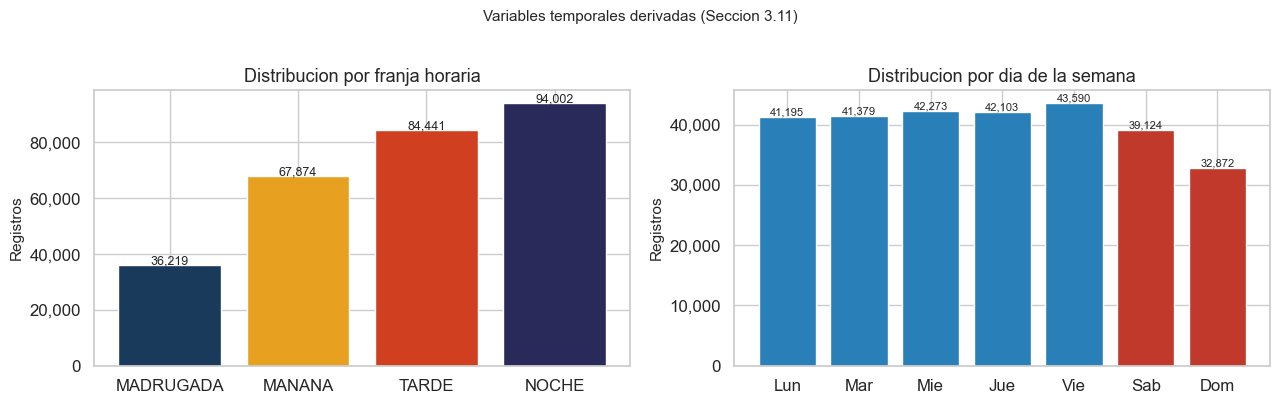

In [28]:
# ============================================================
# VERIFICACION Y DISTRIBUCION DE LAS VARIABLES TEMPORALES
# ============================================================
print("=== hora_num ===")
print(f"  Rango: [{df['hora_num'].min()}, {df['hora_num'].max()}]")
print(f"  Nulos: {df['hora_num'].isnull().sum()}")

print("\n=== franja_horaria ===")
dist_franja = df['franja_horaria'].value_counts().sort_index()
for franja, cnt in dist_franja.items():
    print(f"  {franja:<12} {cnt:>8,}  ({cnt/len(df)*100:.1f}%)")

print("\n=== dia_semana_num ===")
dias_label = {0:'Lunes', 1:'Martes', 2:'Miercoles', 3:'Jueves',
              4:'Viernes', 5:'Sabado', 6:'Domingo'}
dist_dia = df['dia_semana_num'].value_counts().sort_index()
for d, cnt in dist_dia.items():
    print(f"  {d} ({dias_label[d]:<10}) {cnt:>8,}  ({cnt/len(df)*100:.1f}%)")

print("\n=== es_fin_semana ===")
dist_fds = df['es_fin_semana'].value_counts()
n_fds  = dist_fds.get(True, 0)
n_sem  = dist_fds.get(False, 0)
print(f"  Dia de semana (False): {n_sem:>8,}  ({n_sem/len(df)*100:.1f}%)")
print(f"  Fin de semana (True):  {n_fds:>8,}  ({n_fds/len(df)*100:.1f}%)")

# Visualizacion compacta: distribucion por franja y por dia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: franja horaria
colores_franja = ['#1a3a5c', '#e8a020', '#d04020', '#2a2a5a']
franjas_orden  = ['MADRUGADA', 'MANANA', 'TARDE', 'NOCHE']
vals_franja    = [dist_franja.get(f, 0) for f in franjas_orden]
axes[0].bar(franjas_orden, vals_franja, color=colores_franja, edgecolor='white')
axes[0].set_title('Distribucion por franja horaria')
axes[0].set_ylabel('Registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vals_franja):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

# Panel derecho: dia de la semana
dias_nombres = ['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom']
vals_dia = [dist_dia.get(d, 0) for d in range(7)]
colores_dia = ['#c0392b' if d >= 5 else '#2980b9' for d in range(7)]
axes[1].bar(dias_nombres, vals_dia, color=colores_dia, edgecolor='white')
axes[1].set_title('Distribucion por dia de la semana')
axes[1].set_ylabel('Registros')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(vals_dia):
    axes[1].text(i, v + 300, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Variables temporales derivadas (Seccion 3.11)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(f'{PATH_FIGURES}/08_variables_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

El dataset procesado se exporta en formato CSV para garantizar su interoperabilidad con los notebooks subsecuentes del pipeline. Se genera adicionalmente un archivo de estadisticas de preprocesamiento que documenta el impacto cuantitativo de cada filtro aplicado, con fines de reproducibilidad y auditoria metodologica.

In [29]:
# ============================================================
# 4.1 EXPORTACION DEL DATASET LIMPIO EN FORMATO CSV
# ============================================================
RUTA_DATASET = f'{PATH_PROCESSED}/fgj_limpio_2016_2024.csv'

df.to_csv(RUTA_DATASET, index=False, encoding='utf-8')

tamano_mb = os.path.getsize(RUTA_DATASET) / 1e6
print(f"Dataset procesado exportado correctamente.")
print(f"  Ruta:      {RUTA_DATASET}")
print(f"  Tamano:    {tamano_mb:.1f} MB")
print(f"  Registros: {len(df):,}")
print(f"  Columnas:  {df.shape[1]} -> {list(df.columns)}")

Dataset procesado exportado correctamente.
  Ruta:      data/processed/fgj_limpio_2016_2024.csv
  Tamano:    40.8 MB
  Registros: 282,536
  Columnas:  13 -> ['fecha_hecho', 'año_hecho', 'mes_hecho', 'hora_hecho', 'categoria_delito', 'colonia_hecho', 'alcaldia_hecho', 'latitud', 'longitud', 'hora_num', 'franja_horaria', 'dia_semana_num', 'es_fin_semana']


In [30]:
# ============================================================
# 4.2 EXPORTACION DE ESTADISTICAS DE PREPROCESAMIENTO
# Documento de auditoria para trazabilidad del pipeline.
# ============================================================
n_sin_coords    = df_raw.dropna(subset=['latitud', 'longitud']).shape[0]
n_sin_coords    = len(df_raw) - n_sin_coords
n_fuera_periodo = df_raw[~((df_raw['año_hecho'] >= 2016) &
                            (df_raw['año_hecho'] <= 2024))].shape[0]

stats = pd.DataFrame({
    'metrica': [
        'registros_dataset_original',
        'registros_dataset_procesado',
        'porcentaje_retenido',
        'columnas_originales',
        'columnas_procesadas',
        'año_inicio_analisis',
        'año_fin_analisis',
        'alcaldias_representadas',
        'categorias_delictivas',
        'registros_eliminados_sin_coordenadas',
        'registros_eliminados_fuera_periodo',
    ],
    'valor': [
        len(df_raw),
        len(df),
        round(len(df) / len(df_raw) * 100, 2),
        df_raw.shape[1],
        df.shape[1],
        2016,
        2024,
        df['alcaldia_hecho'].nunique(),
        df['categoria_delito'].nunique(),
        n_sin_coords,
        n_fuera_periodo,
    ]
})

RUTA_STATS = f'{PATH_PROCESSED}/estadisticas_preprocesamiento.csv'
stats.to_csv(RUTA_STATS, index=False, encoding='utf-8')

print(f"Estadisticas de preprocesamiento exportadas.")
print(f"  Ruta: {RUTA_STATS}\n")
display(stats)

Estadisticas de preprocesamiento exportadas.
  Ruta: data/processed/estadisticas_preprocesamiento.csv



,metrica,valor
0,registros_dataset_original,2098743.00
1,registros_dataset_procesado,282536.00
2,porcentaje_retenido,13.46
3,columnas_originales,21.00
4,columnas_procesadas,13.00
5,año_inicio_analisis,2016.00
6,año_fin_analisis,2024.00
7,alcaldias_representadas,16.00
8,categorias_delictivas,10.00
9,registros_eliminados_sin_coordenadas,101207.00


In [31]:
# ============================================================
# VERIFICACION DE INTEGRIDAD: RELEER EL ARCHIVO EXPORTADO
# ============================================================
df_verificacion = pd.read_csv(RUTA_DATASET, low_memory=False)

assert df_verificacion.shape == df.shape, "Error de integridad: las dimensiones no coinciden."
print("Verificacion de integridad superada.")
print(f"  Registros leidos del archivo: {len(df_verificacion):,}")
print(f"  Columnas leidas del archivo:  {df_verificacion.shape[1]}")
print(f"\nMuestra del archivo exportado:")
display(df_verificacion.head(3))

Verificacion de integridad superada.
  Registros leidos del archivo: 282,536
  Columnas leidas del archivo:  13

Muestra del archivo exportado:


,fecha_hecho,año_hecho,mes_hecho,hora_hecho,categoria_delito,colonia_hecho,alcaldia_hecho,latitud,longitud,hora_num,franja_horaria,dia_semana_num,es_fin_semana
0,2016-01-01,2016,ENERO,00:20:00,ROBO A TRANSEUNTE EN VIA PUBLICA CON Y SIN VIO...,SAN ANTONIO CULHUACÁN,IZTAPALAPA,19.34080,-99.11431,0,MADRUGADA,4,False
1,2016-01-01,2016,ENERO,03:50:00,ROBO A NEGOCIO CON VIOLENCIA,AGRÍCOLA ORIENTAL,IZTACALCO,19.39370,-99.08147,3,MADRUGADA,4,False
2,2016-01-01,2016,ENERO,03:25:00,LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO,HIDALGO,ALVARO OBREGON,19.39787,-99.20915,3,MADRUGADA,4,False


---

## Conclusiones del Notebook 01

Esta etapa resuelve el problema de label noise que es el punto de partida del proyecto:
sin categorías delictivas estables, no hay firmas confiables, y sin firmas confiables,
no hay embeddings ni trayectorias que valgan.

**Colecta y exploración:** el dataset original tiene 2,098,743 registros con 21 columnas.
El análisis inicial identificó cuatro problemas: registros fuera del rango 2016–2024
(~33,000), registros sin coordenadas geográficas (~101,207), coordenadas fuera del
bounding box de la CDMX (variable), y 357 variantes textuales en el campo `delito`.

**Limpieza:** los filtros en cascada temporal, de coordenadas y de bounding box
eliminaron el 86.5% de los registros originales, reteniendo los 282,536 con mayor
calidad. La reducción de 21 a 9 columnas eliminó variables administrativas, redundantes
o con más del 50% de nulos.

**Armonización de categorías:** la normalización Unicode (NFD) unificó variantes con
y sin acentos. La fusión de FEMINICIDIO con HOMICIDIO DOLOSO y PLAGIO O SECUESTRO con
SECUESTRO (2 pares, totalizando menos de 5 registros) redujo variación semántica trivial.
La selección de las 10 categorías con mayor valor analítico (más de 4,000 registros cada una
en 9 años) garantiza masa estadística suficiente para construir firmas por celda H3-8.

**Validación por TF-IDF (Sección 3.10.4):** la aplicación de TF-IDF con char n-grams (2–4)
y Agglomerative Clustering sobre los 71 strings únicos del campo `delito` confirmó que
los grupos por similitud textual convergen con la taxonomía de la FGJ (NMI=0.830, ARI=0.572,
85.9% de strings asignados correctamente). Esto valida que usar `categoria_delito` como
base de armonización es una decisión estadísticamente sólida, no arbitraria.

**Variables temporales:** se derivaron cuatro variables operativas (`hora_num`,
`franja_horaria`, `dia_semana_num`, `es_fin_semana`) que NB02 usará para construir
el perfil horario y semanal de cada firma espacio-temporal.

**Siguiente paso:** En el notebook 2 se usaran estos 282,536 registros para construir firmas consistentes para nuestros modelos.